In [1]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os
import tkinter as tk
from tkinter import filedialog

# ==========================================
# 🔧 STEP 1: MASTER CONFIGURATION
# ==========================================

FOLDER_PATH   = r'C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Windowed'
FS            = 400.0
USE_FULL_FILE = True  # True = process whole CSV

# ✅ POP-UP FILE PICKER (more notebook-safe)
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

FILENAME = filedialog.askopenfilename(
    initialdir=FOLDER_PATH,
    title="Select PPG CSV File",
    filetypes=[("CSV Files", "*.csv")]
)

root.destroy()

if not FILENAME:
    raise ValueError("❌ No file selected. Please choose a CSV file.")

print(f"📂 Selected File: {os.path.basename(FILENAME)}")

# 2) ✂️ DATA SELECTION
# If SAMPLE_END == 0, we will auto-set it to end of file AFTER loading df
SAMPLE_START = 0
SAMPLE_END   = 0

# 3) Plotting Settings
SUBPLOT_HEIGHT              = 4.0
TIME_VERTICAL_LINE_INTERVAL = 1.0
FREQ_VERTICAL_LINE_INTERVAL = 1.0

# 4) Validity Thresholds
THRESHOLD_RED = 0
THRESHOLD_IR  = 0

# Spike Removal
SPIKE_ENABLE  = False
KERNEL_SIZE   = 51

# Signal Inversion
INVERT_ENABLE = True

# Low Pass Filter
LP_ENABLE     = True
LP_CUTOFF     = 16.0
LP_ORDER      = 4

# High Pass Filter
HP_ENABLE     = True
HP_CUTOFF     = 0.5
HP_ORDER      = 4

# Savitzky-Golay
SG_ENABLE     = False
SG_WINDOW     = 31
SG_POLY       = 3

# Normalization
NORM_SELECTION = 1  # 1=MinMax, 2=ZScore

SQI_LIMITS = {
    'SKEWNESS_MIN': 0.0,   'SKEWNESS_MAX': 2.5,
    'KURTOSIS_MIN': 1.5,   'KURTOSIS_MAX': 7.0,
    'PI_MIN':       0.1,   'PI_MAX':       10.0,
    'SNR_MIN_DB':   5.0,   'SNR_MAX_DB':   25.0,
    'ZCR_MIN':      1.0,   'ZCR_MAX':      4.0
}

def apply_normalization(data, selection=1):
    data = np.asarray(data)
    if data.size == 0:
        return data

    if selection == 1:  # MinMax
        den = np.max(data) - np.min(data)
        if den == 0:
            return np.zeros_like(data)
        return (data - np.min(data)) / den

    elif selection == 2:  # Z-score
        sd = np.std(data)
        if sd == 0:
            return np.zeros_like(data)
        return (data - np.mean(data)) / sd

    return data

print("✅ Configuration Loaded.")
print(f"📌 FS={FS} Hz | Plot Height={SUBPLOT_HEIGHT} inches")
print(f"📏 Grid: Time={TIME_VERTICAL_LINE_INTERVAL}s | Freq={FREQ_VERTICAL_LINE_INTERVAL}Hz")

# ✅ NOTE:
# After you load the CSV into df later, do:
# if USE_FULL_FILE:
#     SAMPLE_START = 0
#     SAMPLE_END = len(df)
# elif SAMPLE_END == 0:
#     SAMPLE_END = len(df)
# total_samples = SAMPLE_END - SAMPLE_START
# plot_time = total_samples / FS
# print(f"⏱️ Duration: {plot_time:.2f}s")

📂 Selected File: Raafiq(22-enc-05)v1_Win0.csv
✅ Configuration Loaded.
📌 FS=400.0 Hz | Plot Height=4.0 inches
📏 Grid: Time=1.0s | Freq=1.0Hz


✅ Processing Range: 6000 samples (15.00 seconds).


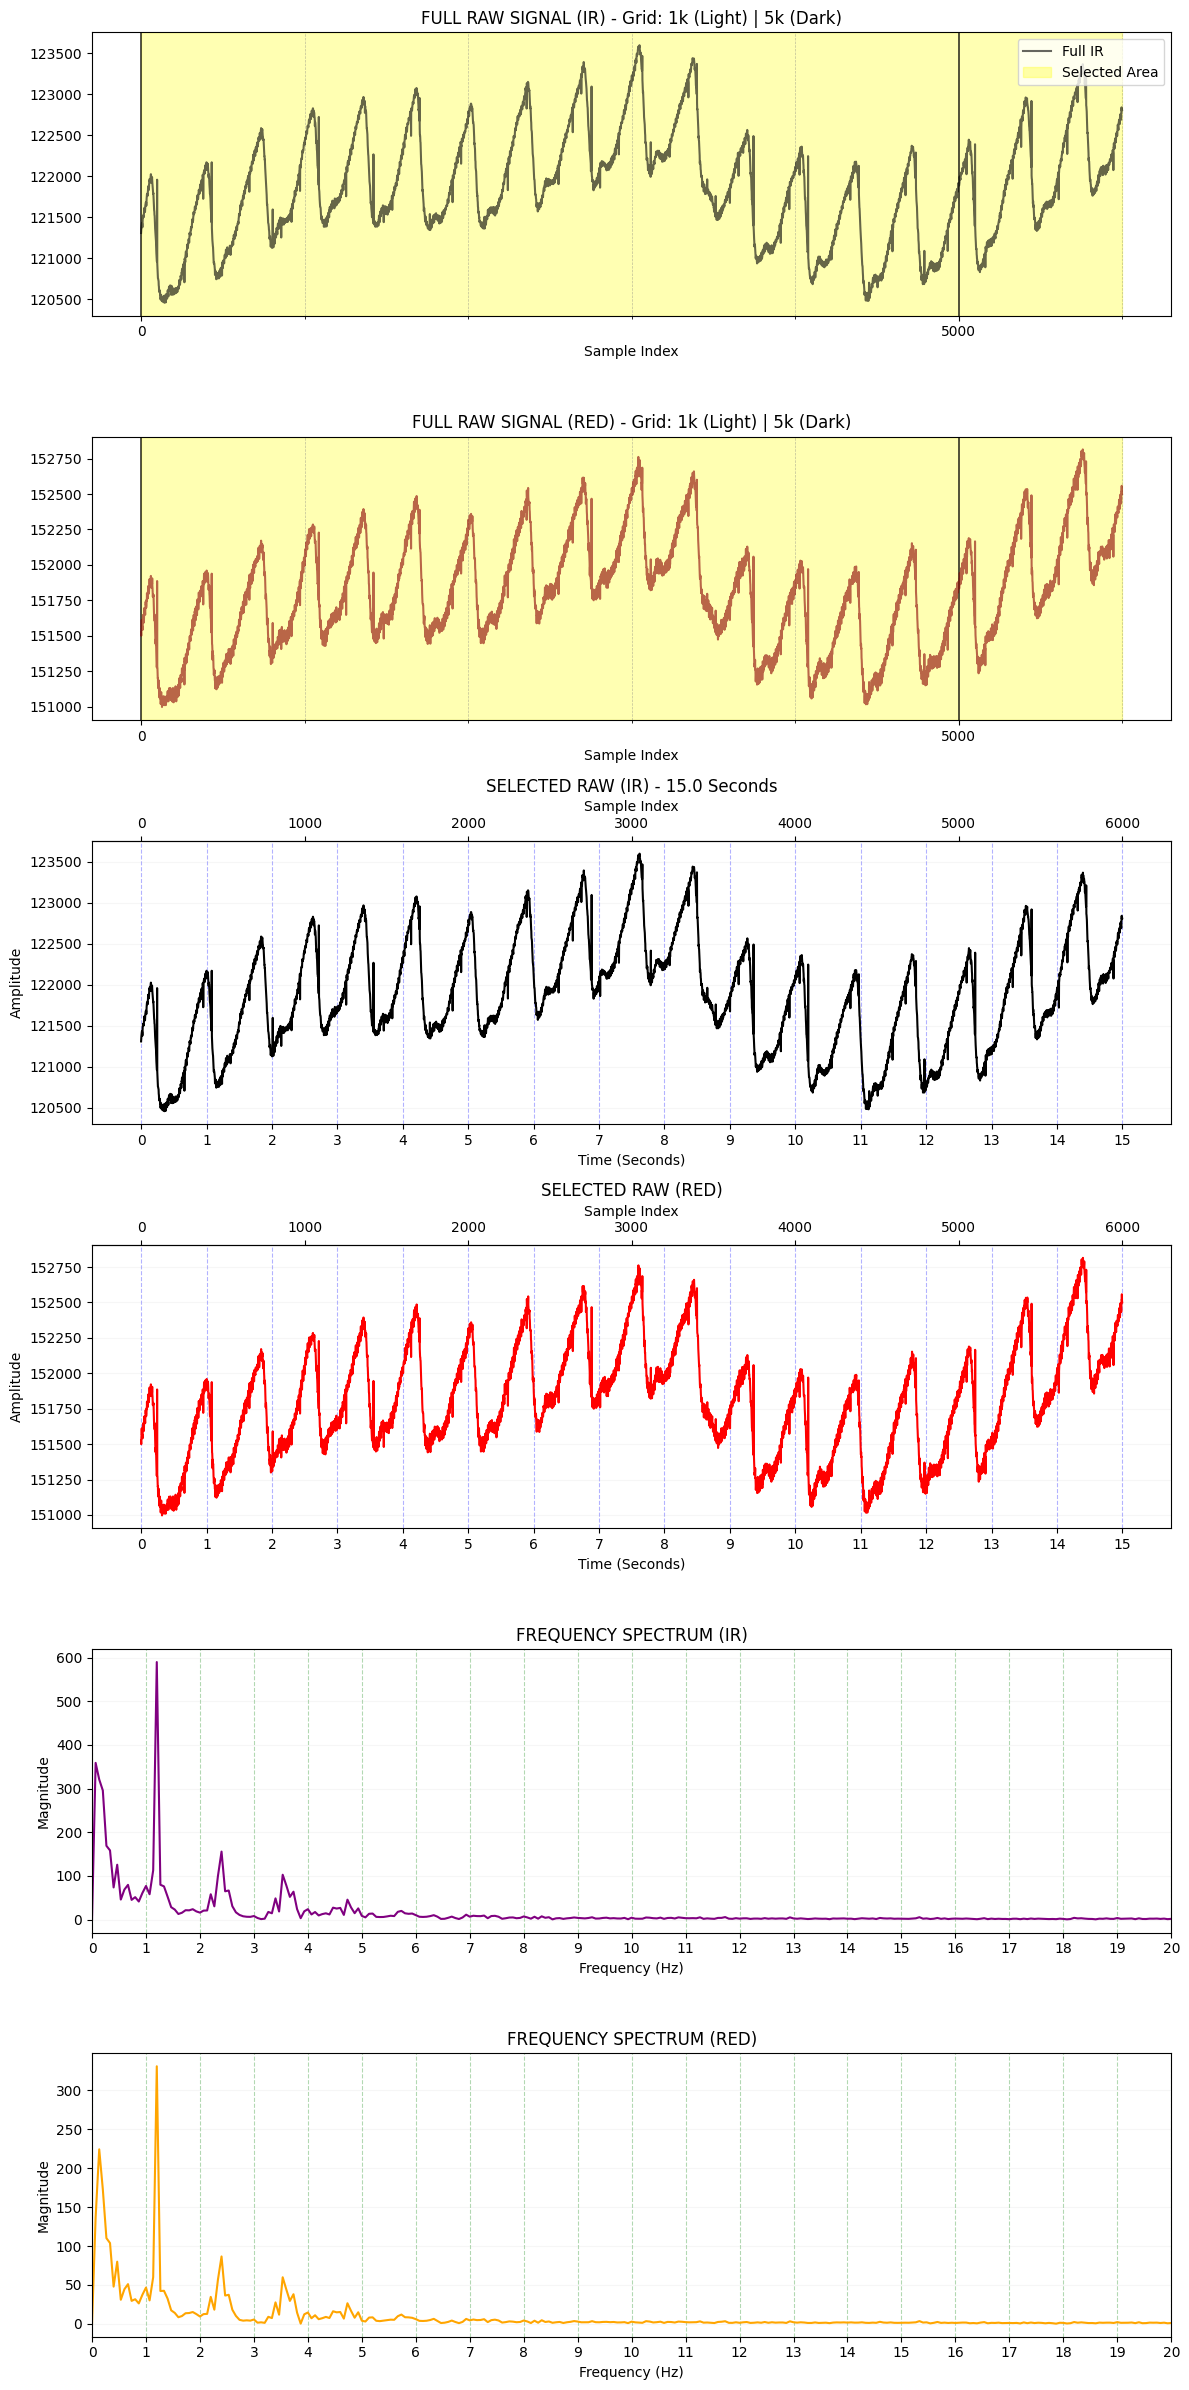

In [2]:
# ==========================================
# ⚙️ STEP 2: LOAD, SELECT, TIME & FREQ PLOTS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.fft import fft, fftfreq

# 1. Load CSV
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()

rename_map = {
    'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 
    'RED VALUE': 'RED', 'IR VALUE': 'IR',
    'RED_RAW': 'RED',   'IR_RAW': 'IR'
}
df = df.rename(columns=rename_map)

# 2. Apply Validity Thresholds
mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
full_clean_df = df[mask].copy()
full_clean_df = full_clean_df.reset_index(drop=True)

# 3. ✂️ APPLY SELECTION
if USE_FULL_FILE:
    selected_df = full_clean_df.copy()
    SAMPLE_START = 0
    SAMPLE_END = len(selected_df)
else:
    s_end = min(SAMPLE_END, len(full_clean_df))
    selected_df = full_clean_df.iloc[SAMPLE_START:s_end].copy()

# --- FFT HELPER ---
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data)
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# --- SAFETY CHECK & PLOTTING ---
if len(selected_df) < 50:
    print(f"❌ CRITICAL ERROR: Selected range is too short ({len(selected_df)} samples)!")
else:
    print(f"✅ Processing Range: {len(selected_df)} samples ({len(selected_df)/FS:.2f} seconds).")

    # Generate Time Axis (Seconds)
    time_axis = np.arange(len(selected_df)) / FS
    
    # DYNAMIC FIGURE SIZE
    total_fig_height = SUBPLOT_HEIGHT * 6
    fig, axes = plt.subplots(6, 1, figsize=(12, total_fig_height))
    plt.subplots_adjust(hspace=0.6) # Increase spacing for dual axes

    # --- PLOT 1: FULL Data (IR) ---
    axes[0].plot(full_clean_df['IR'].values, color='black', alpha=0.6, label='Full IR')
    axes[0].axvspan(SAMPLE_START, SAMPLE_END, color='yellow', alpha=0.3, label='Selected Area')
    
    # NEW: Multi-level Grid & Labeling (Every 5000 and 1000)
    axes[0].xaxis.set_major_locator(ticker.MultipleLocator(5000))
    axes[0].xaxis.set_minor_locator(ticker.MultipleLocator(1000))
    axes[0].grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1.2, alpha=0.8)
    axes[0].grid(True, which='minor', axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    axes[0].set_xticks(np.arange(0, len(full_clean_df), 5000)) # X-labeling every 5000
    axes[0].set_title('FULL RAW SIGNAL (IR) - Grid: 1k (Light) | 5k (Dark)')
    axes[0].set_xlabel('Sample Index')
    axes[0].legend(loc='upper right')

    # --- PLOT 2: FULL Data (RED) ---
    axes[1].plot(full_clean_df['RED'].values, color='darkred', alpha=0.6, label='Full RED')
    axes[1].axvspan(SAMPLE_START, SAMPLE_END, color='yellow', alpha=0.3)
    
    # NEW: Multi-level Grid & Labeling (Every 5000 and 1000)
    axes[1].xaxis.set_major_locator(ticker.MultipleLocator(5000))
    axes[1].xaxis.set_minor_locator(ticker.MultipleLocator(1000))
    axes[1].grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1.2, alpha=0.8)
    axes[1].grid(True, which='minor', axis='x', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
            
    axes[1].set_xticks(np.arange(0, len(full_clean_df), 5000)) # X-labeling every 5000
    axes[1].set_title('FULL RAW SIGNAL (RED) - Grid: 1k (Light) | 5k (Dark)')
    axes[1].set_xlabel('Sample Index')

    # --- PLOT 3: SELECTED IR (Time Axis) ---
    axes[2].plot(time_axis, selected_df['IR'].values, color='black', linewidth=1.5)
    axes[2].set_title(f'SELECTED RAW (IR) - {len(selected_df)/FS:.1f} Seconds')
    axes[2].set_ylabel('Amplitude')
    axes[2].set_xlabel('Time (Seconds)') 
    
    sec_ax1 = axes[2].secondary_xaxis('top', functions=(lambda x: x*FS, lambda x: x/FS))
    sec_ax1.set_xlabel('Sample Index')

    # --- PLOT 4: SELECTED RED (Time Axis) ---
    axes[3].plot(time_axis, selected_df['RED'].values, color='red', linewidth=1.5)
    axes[3].set_title(f'SELECTED RAW (RED)')
    axes[3].set_ylabel('Amplitude')
    axes[3].set_xlabel('Time (Seconds)') 

    sec_ax2 = axes[3].secondary_xaxis('top', functions=(lambda x: x*FS, lambda x: x/FS))
    sec_ax2.set_xlabel('Sample Index')

    # --- TIME VERTICAL LINES ---
    if TIME_VERTICAL_LINE_INTERVAL > 0:
        pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
        for ax in [axes[2], axes[3]]:
            ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
            ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
            ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

    # --- PLOT 5: FFT IR ---
    xf_ir, yf_ir = compute_fft(selected_df['IR'].values - np.mean(selected_df['IR'].values), FS)
    axes[4].plot(xf_ir, yf_ir, color='purple')
    axes[4].set_title('FREQUENCY SPECTRUM (IR)')
    axes[4].set_ylabel('Magnitude')
    axes[4].set_xlabel('Frequency (Hz)')
    axes[4].set_xlim(0, 20) 
    
    # --- PLOT 6: FFT RED ---
    xf_red, yf_red = compute_fft(selected_df['RED'].values - np.mean(selected_df['RED'].values), FS)
    axes[5].plot(xf_red, yf_red, color='orange')
    axes[5].set_title('FREQUENCY SPECTRUM (RED)')
    axes[5].set_ylabel('Magnitude')
    axes[5].set_xlabel('Frequency (Hz)')
    axes[5].set_xlim(0, 20) 

    # --- FREQUENCY VERTICAL LINES ---
    if FREQ_VERTICAL_LINE_INTERVAL > 0:
        pass # grid_freqs = np.arange(0, 20, FREQ_VERTICAL_LINE_INTERVAL)
        for ax in [axes[4], axes[5]]:
            ax.xaxis.set_major_locator(ticker.MultipleLocator(FREQ_VERTICAL_LINE_INTERVAL))
            ax.grid(True, which='major', axis='x', color='green', linestyle='--', alpha=0.3)
            ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

    plt.tight_layout()
    plt.show()

⚠️ SPIKE REMOVAL: DISABLED (Skipping...)


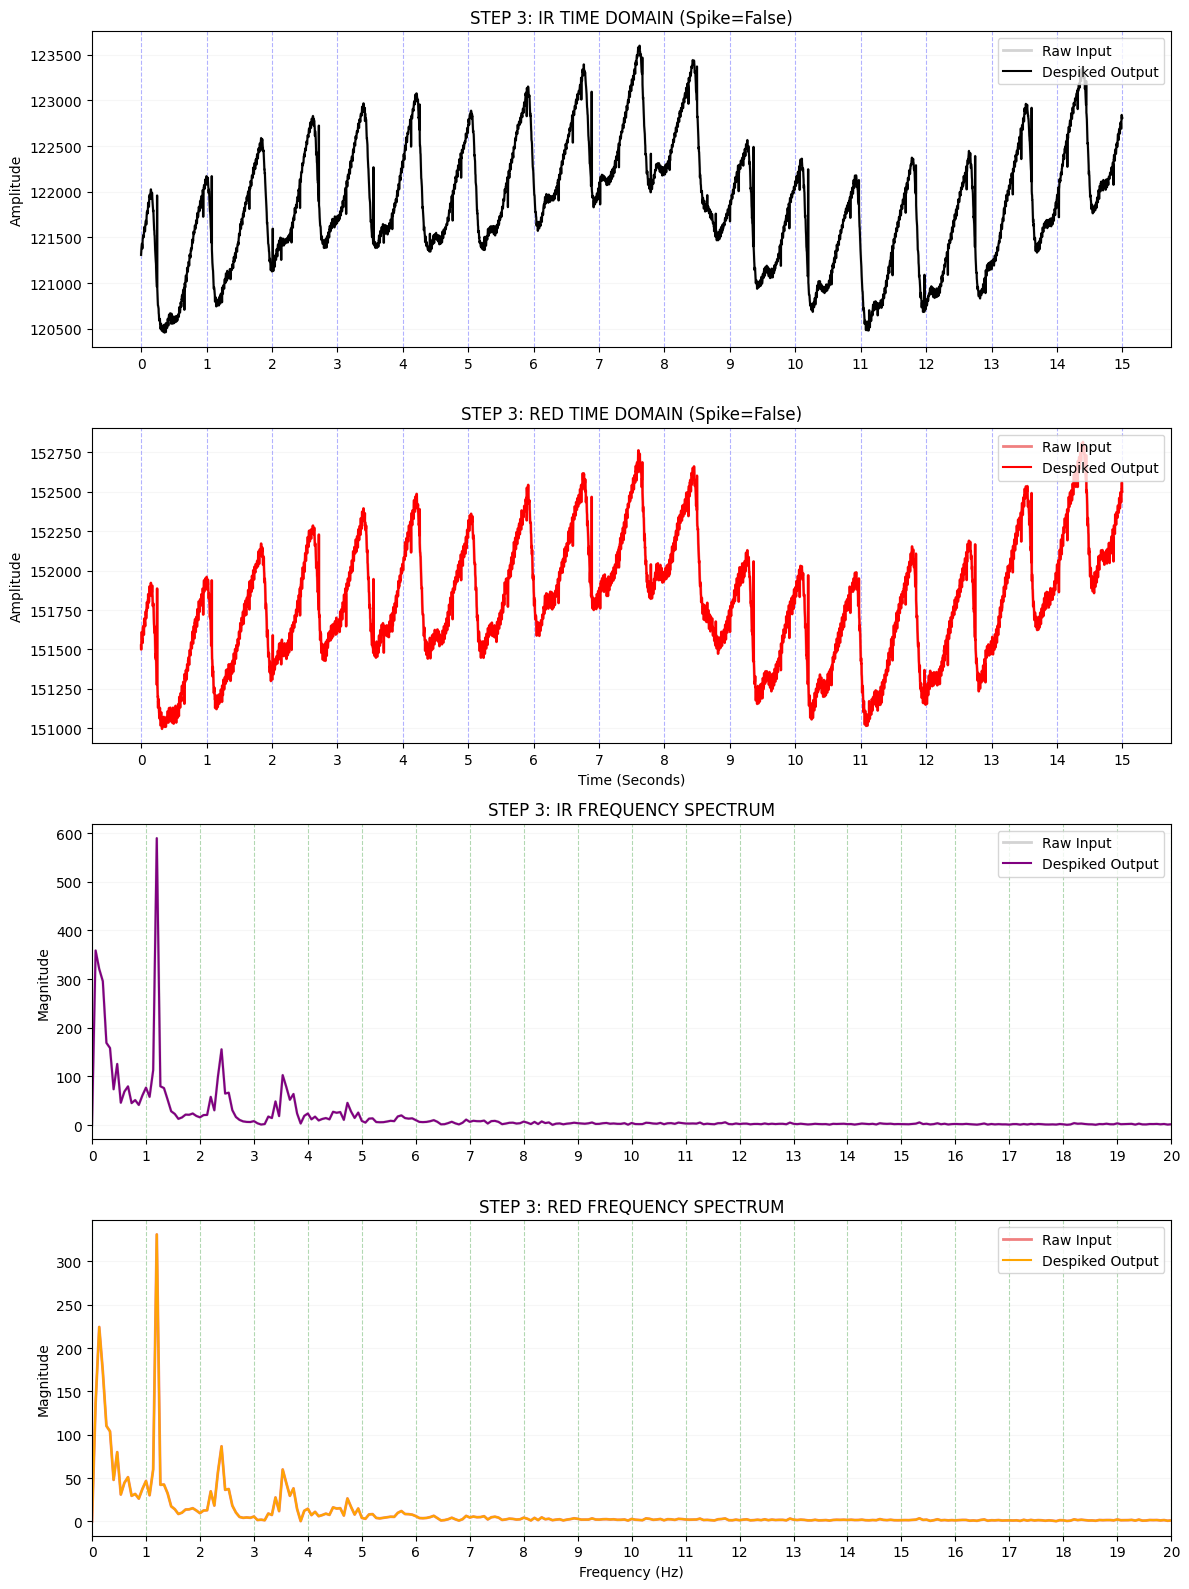

In [3]:
# ==========================================
# ⚙️ STEP 3: SPIKE REMOVAL (TIME + FREQ)
# ==========================================
import scipy.signal as signal
from scipy.fft import fft, fftfreq

# 1. Check Toggle Switch & Process
if SPIKE_ENABLE:
    print(f"⚡ SPIKE REMOVAL: ENABLED (Kernel Size: {KERNEL_SIZE})")
    ir_despiked  = signal.medfilt(selected_df['IR'].values, kernel_size=KERNEL_SIZE)
    red_despiked = signal.medfilt(selected_df['RED'].values, kernel_size=KERNEL_SIZE)
else:
    print("⚠️ SPIKE REMOVAL: DISABLED (Skipping...)")
    ir_despiked  = selected_df['IR'].values.copy()
    red_despiked = selected_df['RED'].values.copy()

# 2. FFT Helper Function
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data)) # Remove DC offset
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# 3. Setup Plotting
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4  # 4 Plots now
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR (Time) ---
axes[0].plot(time_axis, selected_df['IR'].values, color='lightgray', label='Raw Input', linewidth=2)
axes[0].plot(time_axis, ir_despiked, color='black', linewidth=1.5, label='Despiked Output')
axes[0].set_title(f'STEP 3: IR TIME DOMAIN (Spike={SPIKE_ENABLE})')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED (Time) ---
axes[1].plot(time_axis, selected_df['RED'].values, color='lightcoral', label='Raw Input', linewidth=2)
axes[1].plot(time_axis, red_despiked, color='red', linewidth=1.5, label='Despiked Output')
axes[1].set_title(f'STEP 3: RED TIME DOMAIN (Spike={SPIKE_ENABLE})')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- VERTICAL LINES (Time) ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

# --- PLOT 3: IR (Frequency) ---
xf_raw, yf_raw = compute_fft(selected_df['IR'].values, FS)
xf_out, yf_out = compute_fft(ir_despiked, FS)

axes[2].plot(xf_raw, yf_raw, color='lightgray', label='Raw Input', linewidth=2)
axes[2].plot(xf_out, yf_out, color='purple', label='Despiked Output', linewidth=1.5)
axes[2].set_title('STEP 3: IR FREQUENCY SPECTRUM')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 20)
axes[2].legend(loc='upper right')

# --- PLOT 4: RED (Frequency) ---
xf_raw_r, yf_raw_r = compute_fft(selected_df['RED'].values, FS)
xf_out_r, yf_out_r = compute_fft(red_despiked, FS)

axes[3].plot(xf_raw_r, yf_raw_r, color='lightcoral', label='Raw Input', linewidth=2)
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Despiked Output', linewidth=1.5)
axes[3].set_title('STEP 3: RED FREQUENCY SPECTRUM')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 20)
axes[3].legend(loc='upper right')

# --- VERTICAL LINES (Frequency) ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_freqs = np.arange(0, 20, FREQ_VERTICAL_LINE_INTERVAL)
    for ax in [axes[2], axes[3]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(FREQ_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='green', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.


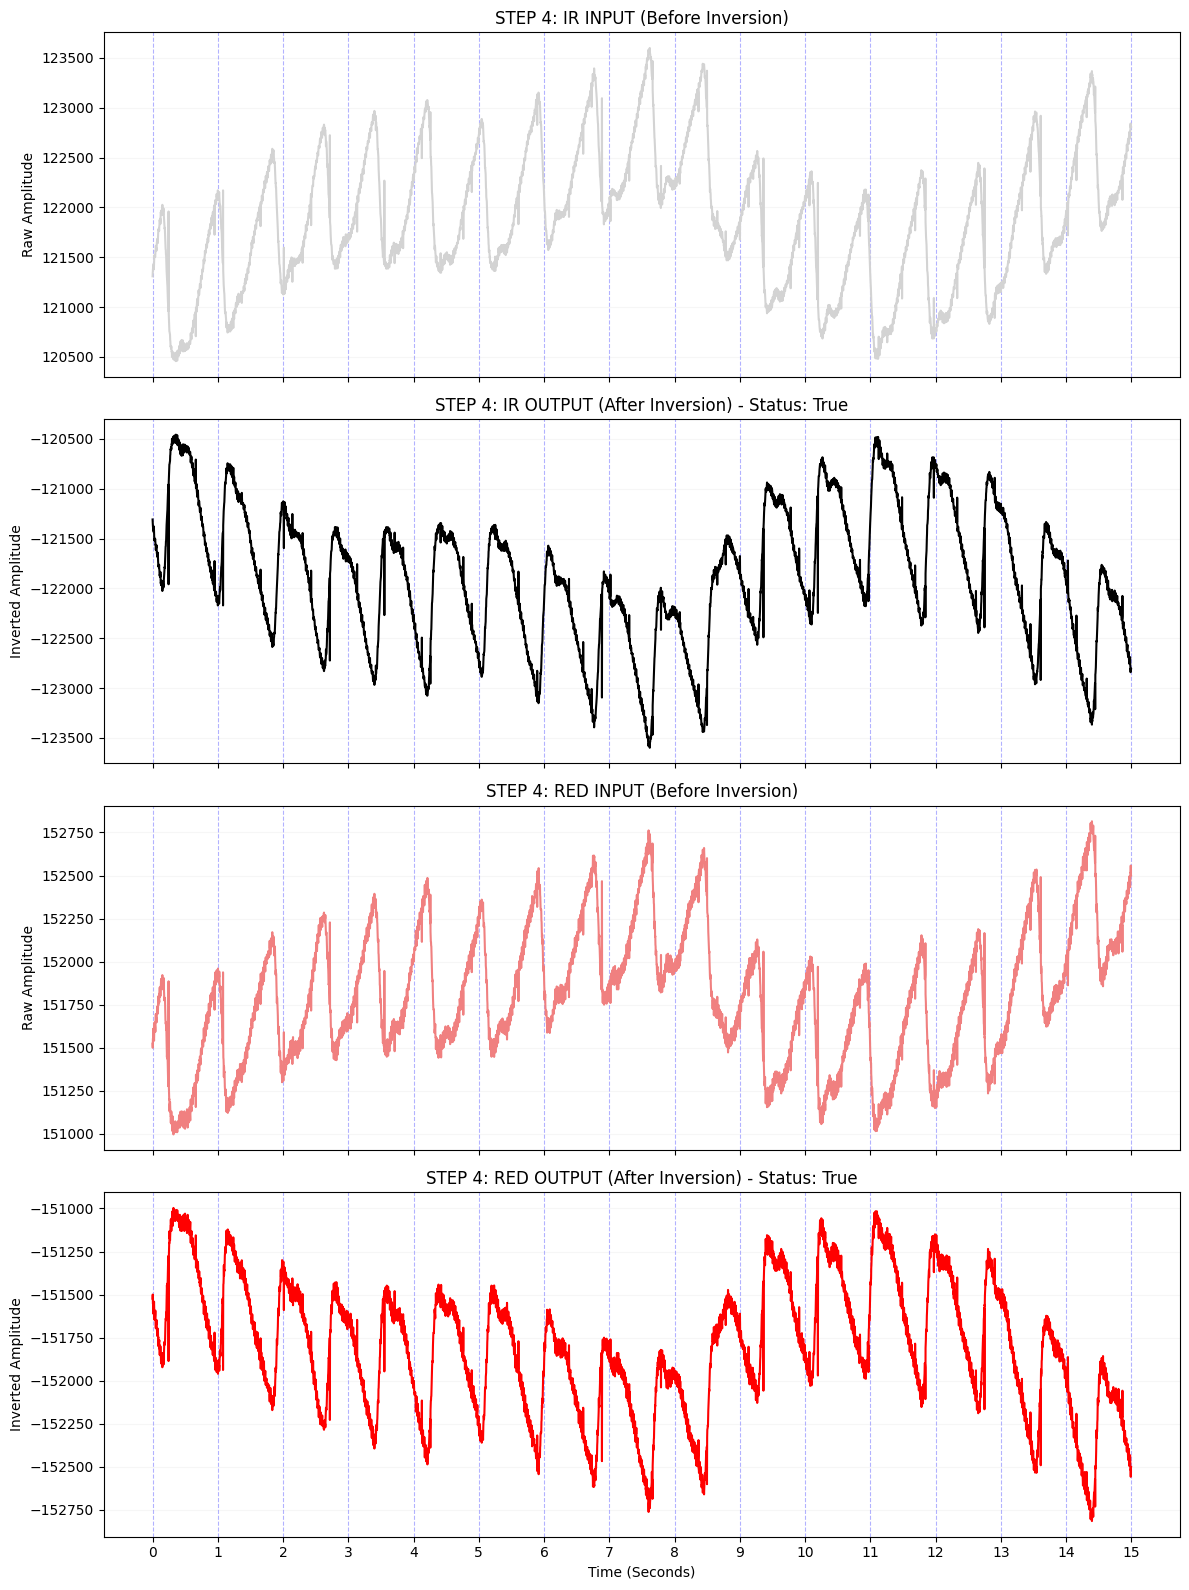

In [4]:
# ==========================================
# ⚙️ STEP 4: SIGNAL INVERSION
# ==========================================
# Fixes Morphology: MAX30102 raw values drop during a pulse.
# We multiply by -1 so the systolic peak points UP.

# 1. Apply Logic
if INVERT_ENABLE:
    print("🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.")
    ir_inverted  = ir_despiked * -1
    red_inverted = red_despiked * -1
else:
    print("➡️ INVERSION SKIPPED: Passing signal through.")
    ir_inverted  = ir_despiked
    red_inverted = red_despiked

# 2. Setup Plotting (4 Separate Rows)
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4 

fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height), sharex=True)
plt.subplots_adjust(hspace=0.6) # Increase spacing between plots

# --- PLOT 1: IR INPUT (Before) ---
axes[0].plot(time_axis, ir_despiked, color='lightgray', linewidth=1.5)
axes[0].set_title(f'STEP 4: IR INPUT (Before Inversion)')
axes[0].set_ylabel('Raw Amplitude')

# --- PLOT 2: IR OUTPUT (After) ---
axes[1].plot(time_axis, ir_inverted, color='black', linewidth=1.5)
axes[1].set_title(f'STEP 4: IR OUTPUT (After Inversion) - Status: {INVERT_ENABLE}')
axes[1].set_ylabel('Inverted Amplitude')

# --- PLOT 3: RED INPUT (Before) ---
axes[2].plot(time_axis, red_despiked, color='lightcoral', linewidth=1.5)
axes[2].set_title(f'STEP 4: RED INPUT (Before Inversion)')
axes[2].set_ylabel('Raw Amplitude')

# --- PLOT 4: RED OUTPUT (After) ---
axes[3].plot(time_axis, red_inverted, color='red', linewidth=1.5)
axes[3].set_title(f'STEP 4: RED OUTPUT (After Inversion) - Status: {INVERT_ENABLE}')
axes[3].set_ylabel('Inverted Amplitude')
axes[3].set_xlabel('Time (Seconds)')

# --- VERTICAL LINES (Time) ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in axes:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

⚡ LOW-PASS FILTER: ENABLED (Cutoff: 16.0Hz, Order: 4)


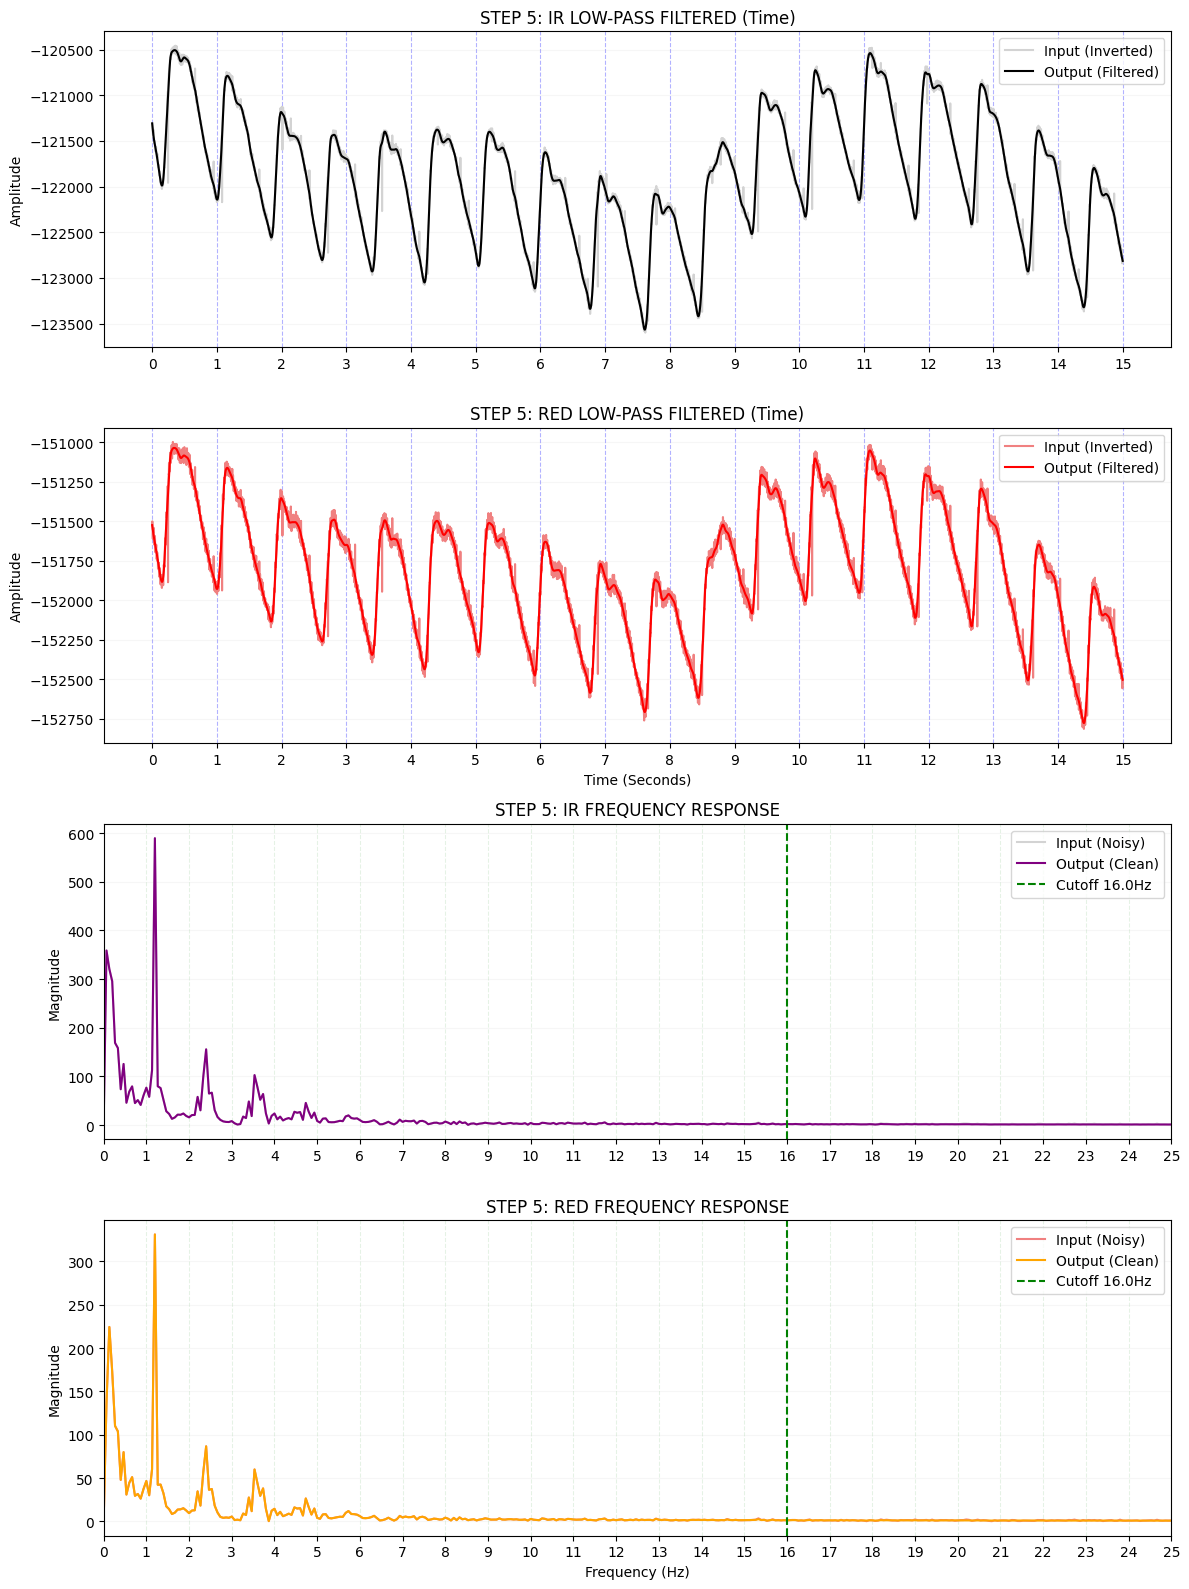

In [5]:
# ==========================================
# ⚙️ STEP 5: LOW-PASS FILTER (Noise Removal)
# ==========================================
# Removes high-frequency noise (muscle movement, electrical jitter).
# Crucial for revealing the "Dicrotic Notch".

# 1. Apply Filter Logic
if LP_ENABLE:
    print(f"⚡ LOW-PASS FILTER: ENABLED (Cutoff: {LP_CUTOFF}Hz, Order: {LP_ORDER})")
    
    nyquist = 0.5 * FS
    # Design Butterworth Filter (SOS mode for stability)
    sos = signal.butter(LP_ORDER, LP_CUTOFF / nyquist, btype='low', output='sos')
    
    # Apply Zero-Phase Filter (filtfilt)
    ir_filtered  = signal.sosfiltfilt(sos, ir_inverted)
    red_filtered = signal.sosfiltfilt(sos, red_inverted)
else:
    print("⚠️ LOW-PASS FILTER: DISABLED (Skipping...)")
    ir_filtered  = ir_inverted
    red_filtered = red_inverted

# ==========================================
# ➕ NEW UPDATE: EXTRACT DC COMPONENT HERE
# ==========================================
# We calculate DC from the Low-Passed signal (Baseline)
# before we strip it away with the High-Pass filter in the next step.
dc_ir_val  = np.mean(ir_filtered)
dc_red_val = np.mean(red_filtered)

# 2. FFT Helper (Local definition for safety)
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data)) # Remove DC
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# 3. Setup Plotting (Time + Frequency)
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR TIME DOMAIN ---
axes[0].plot(time_axis, ir_inverted, color='lightgray', label='Input (Inverted)', linewidth=1.5)
axes[0].plot(time_axis, ir_filtered, color='black', label='Output (Filtered)', linewidth=1.5)
axes[0].set_title(f'STEP 5: IR LOW-PASS FILTERED (Time)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED TIME DOMAIN ---
axes[1].plot(time_axis, red_inverted, color='lightcoral', label='Input (Inverted)', linewidth=1.5)
axes[1].plot(time_axis, red_filtered, color='red', label='Output (Filtered)', linewidth=1.5)
axes[1].set_title(f'STEP 5: RED LOW-PASS FILTERED (Time)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- TIME VERTICAL LINES ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

# --- PLOT 3: IR FREQUENCY SPECTRUM ---
xf_in, yf_in   = compute_fft(ir_inverted, FS)
xf_out, yf_out = compute_fft(ir_filtered, FS)

axes[2].plot(xf_in, yf_in, color='lightgray', label='Input (Noisy)', linewidth=1.5)
axes[2].plot(xf_out, yf_out, color='purple', label='Output (Clean)', linewidth=1.5)
axes[2].axvline(LP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {LP_CUTOFF}Hz') # Mark Cutoff
axes[2].set_title('STEP 5: IR FREQUENCY RESPONSE')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 25) # Zoom to see the cutoff effect
axes[2].legend(loc='upper right')

# --- PLOT 4: RED FREQUENCY SPECTRUM ---
xf_in_r, yf_in_r   = compute_fft(red_inverted, FS)
xf_out_r, yf_out_r = compute_fft(red_filtered, FS)

axes[3].plot(xf_in_r, yf_in_r, color='lightcoral', label='Input (Noisy)', linewidth=1.5)
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Output (Clean)', linewidth=1.5)
axes[3].axvline(LP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {LP_CUTOFF}Hz')
axes[3].set_title('STEP 5: RED FREQUENCY RESPONSE')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 25)
axes[3].legend(loc='upper right')

# --- FREQ VERTICAL LINES ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_freqs = np.arange(0, 25, FREQ_VERTICAL_LINE_INTERVAL)
    for ax in [axes[2], axes[3]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(FREQ_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='green', linestyle='--', alpha=0.1)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

ℹ️ SG SMOOTHING: DISABLED (Skipping...)


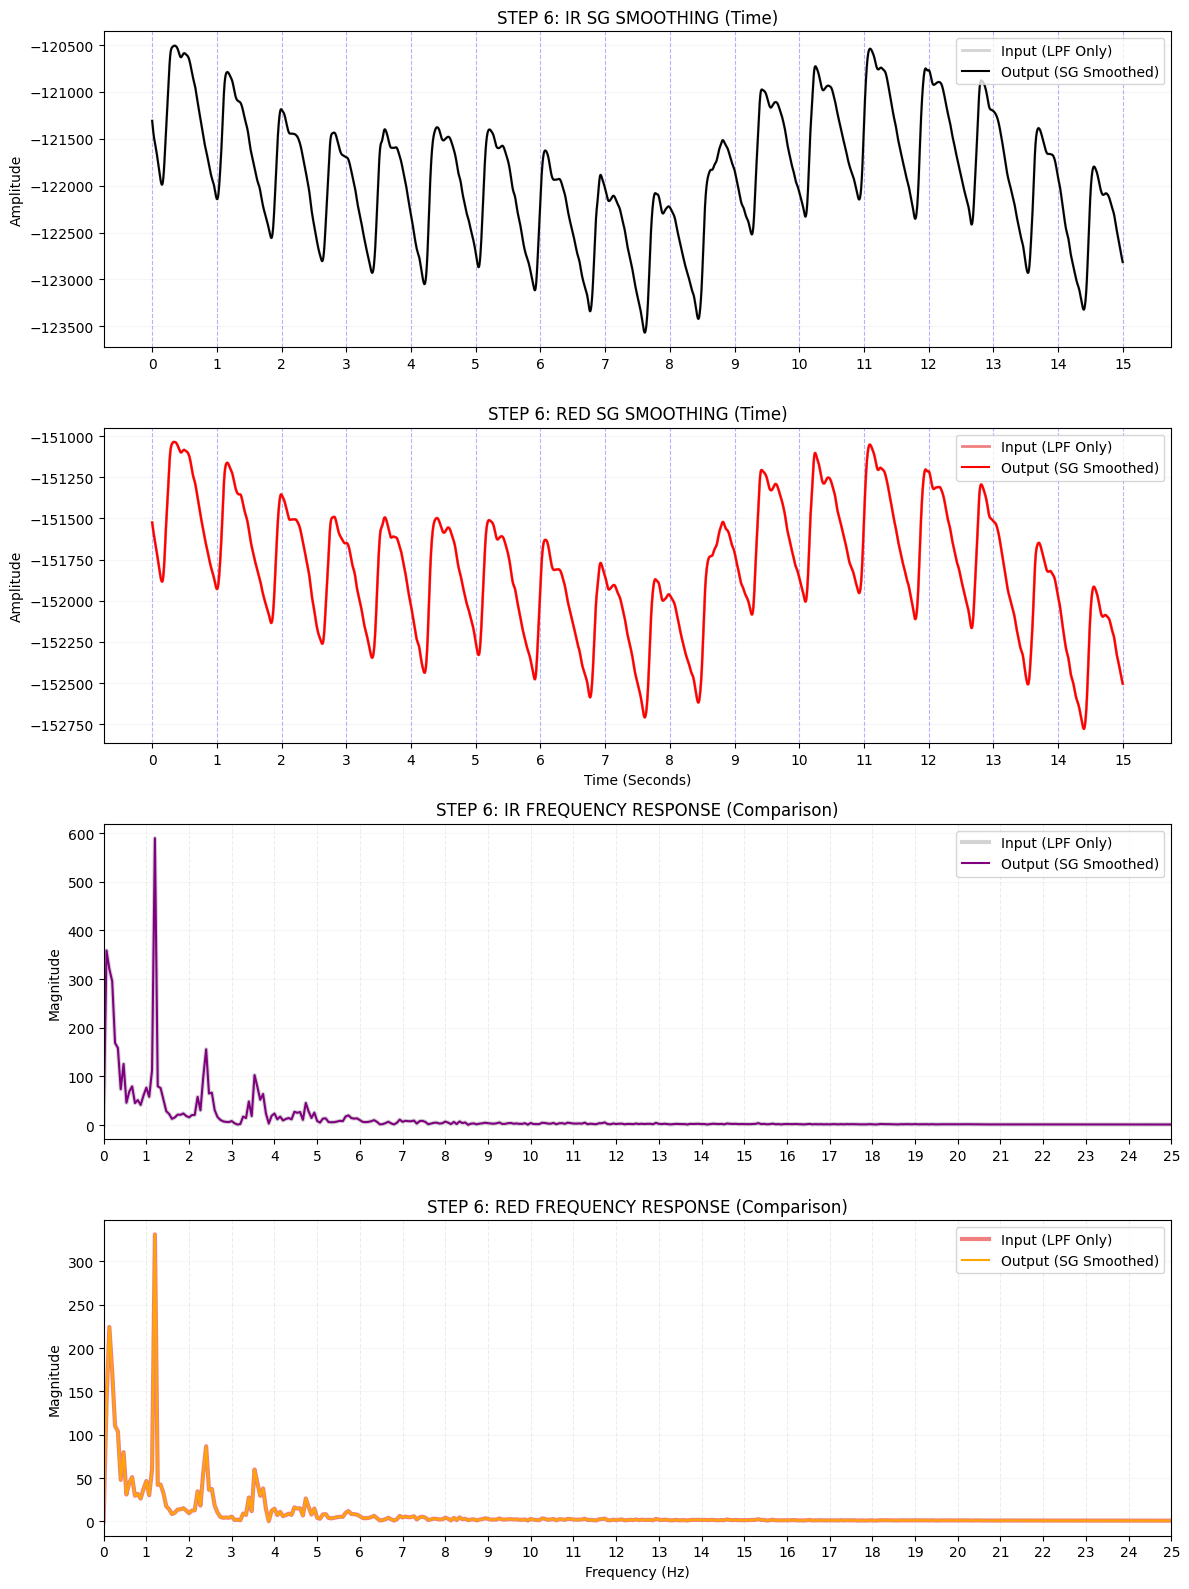

✅ Step 6 Done. Output variables: ir_smoothed, red_smoothed


In [6]:
# ==========================================
# ⚙️ STEP 6: SAVITZKY-GOLAY SMOOTHING
# ==========================================
# "Polishes" the signal while preserving peak sharpness better than standard LPF.
# Input: ir_filtered, red_filtered (from Step 5)
# Output: ir_smoothed, red_smoothed

# --- 1. Safety Check (Prevents Crashes) ---
safe_window = int(SG_WINDOW)
safe_poly   = int(SG_POLY)

# Rule: Window must be ODD
if safe_window % 2 == 0:
    safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be ODD)")

# Rule: Window must be > Poly Order
if safe_window <= safe_poly:
    safe_window = safe_poly + 2
    if safe_window % 2 == 0: safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be > Poly Order)")

# --- 2. Apply Filter ---
if SG_ENABLE:
    print(f"✨ SG SMOOTHING: ENABLED (Window: {safe_window}, Poly: {safe_poly})")
    ir_smoothed  = signal.savgol_filter(ir_filtered, window_length=safe_window, polyorder=safe_poly)
    red_smoothed = signal.savgol_filter(red_filtered, window_length=safe_window, polyorder=safe_poly)
else:
    print("ℹ️ SG SMOOTHING: DISABLED (Skipping...)")
    ir_smoothed  = ir_filtered.copy()
    red_smoothed = red_filtered.copy()

# --- 3. FFT Helper ---
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# --- 4. Setup Plotting ---
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR TIME DOMAIN ---
axes[0].plot(time_axis, ir_filtered, color='lightgray', label='Input (LPF Only)', linewidth=2)
axes[0].plot(time_axis, ir_smoothed, color='black', label='Output (SG Smoothed)', linewidth=1.5)
axes[0].set_title(f'STEP 6: IR SG SMOOTHING (Time)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED TIME DOMAIN ---
axes[1].plot(time_axis, red_filtered, color='lightcoral', label='Input (LPF Only)', linewidth=2)
axes[1].plot(time_axis, red_smoothed, color='red', label='Output (SG Smoothed)', linewidth=1.5)
axes[1].set_title(f'STEP 6: RED SG SMOOTHING (Time)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- TIME VERTICAL LINES ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

# --- PLOT 3: IR FREQUENCY SPECTRUM (Comparison) ---
xf_in, yf_in   = compute_fft(ir_filtered, FS)
xf_out, yf_out = compute_fft(ir_smoothed, FS)

axes[2].plot(xf_in, yf_in, color='lightgray', label='Input (LPF Only)', linewidth=3) # Thicker background
axes[2].plot(xf_out, yf_out, color='purple', label='Output (SG Smoothed)', linewidth=1.5)
axes[2].set_title('STEP 6: IR FREQUENCY RESPONSE (Comparison)')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 25)
axes[2].legend(loc='upper right')

# --- PLOT 4: RED FREQUENCY SPECTRUM (Comparison) ---
xf_in_r, yf_in_r   = compute_fft(red_filtered, FS)
xf_out_r, yf_out_r = compute_fft(red_smoothed, FS) 

axes[3].plot(xf_in_r, yf_in_r, color='lightcoral', label='Input (LPF Only)', linewidth=3) # Thicker background
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Output (SG Smoothed)', linewidth=1.5)
axes[3].set_title('STEP 6: RED FREQUENCY RESPONSE (Comparison)')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 25)
axes[3].legend(loc='upper right')

# --- FREQ VERTICAL LINES ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_freqs = np.arange(0, 25, FREQ_VERTICAL_LINE_INTERVAL)
    for ax in [axes[2], axes[3]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(FREQ_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='green', linestyle='--', alpha=0.1)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

print("✅ Step 6 Done. Output variables: ir_smoothed, red_smoothed")

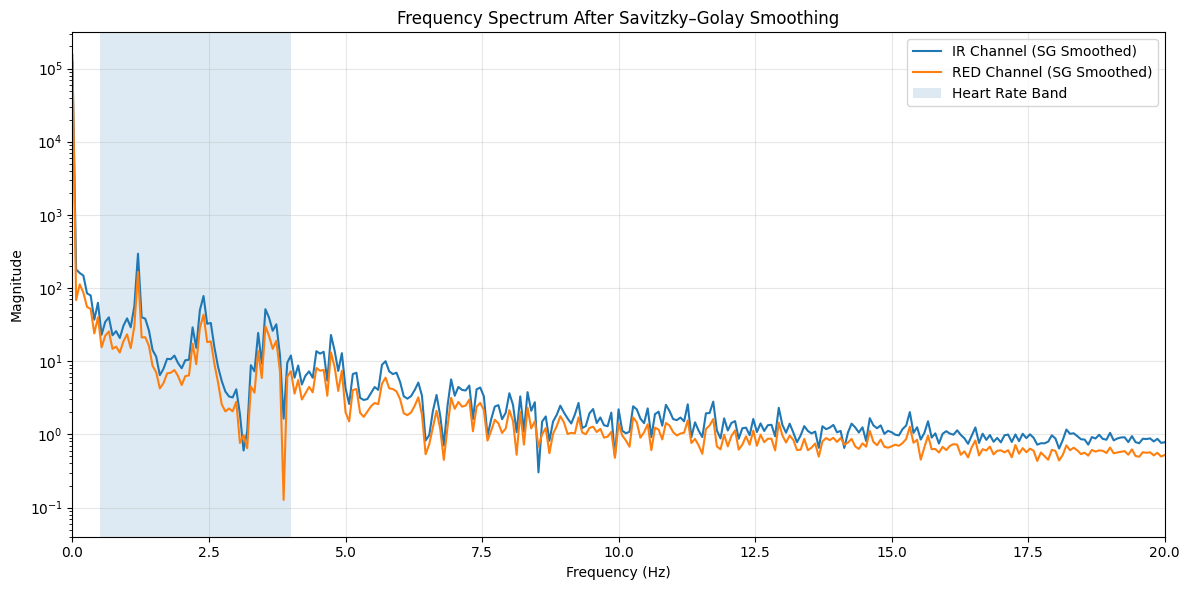

In [7]:
# ==========================================
# 📈 FREQUENCY DOMAIN ANALYSIS (FFT)
# ==========================================

def compute_fft(signal_data, fs):
    N = len(signal_data)
    fft_vals = np.fft.fft(signal_data)
    fft_vals = np.abs(fft_vals) / N
    freqs = np.fft.fftfreq(N, d=1/fs)
    return freqs[:N//2], fft_vals[:N//2]

# Compute FFTs
freq_ir, fft_ir = compute_fft(ir_filtered, FS)
freq_red, fft_red = compute_fft(red_filtered, FS)

# ==========================================
# 📊 FFT PLOTS
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(freq_ir, fft_ir, label='IR Channel (SG Smoothed)', linewidth=1.5)
plt.plot(freq_red, fft_red, label='RED Channel (SG Smoothed)', linewidth=1.5)

# Physiological heart rate band (0.5–4 Hz)
plt.axvspan(0.5, 4.0, alpha=0.15, label='Heart Rate Band')

plt.title("Frequency Spectrum After Savitzky–Golay Smoothing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 20)          # PPG useful range
plt.yscale("log")        # Better visualization
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


⚡ HIGH-PASS FILTER: ENABLED (Cutoff: 0.5Hz, Order: 4)
   -> DC Offset and Breathing Drift Removed.


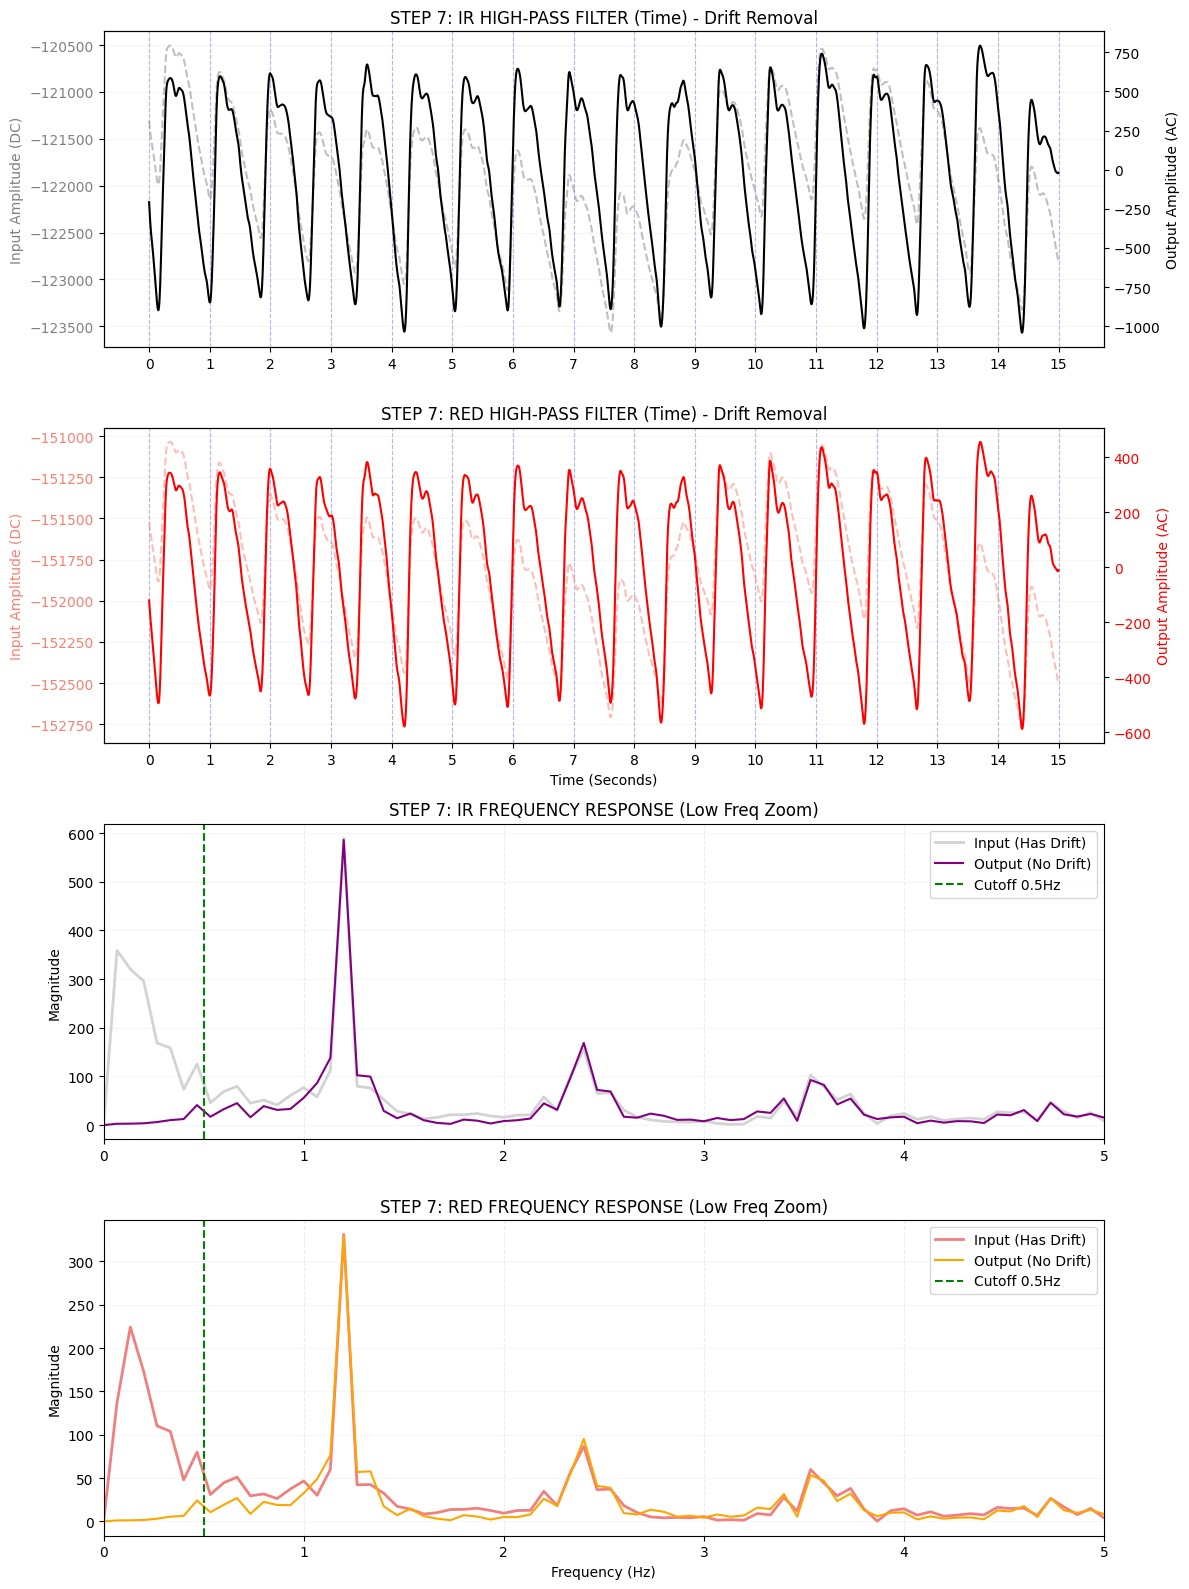

✅ Step 7 Done. Output variables: ir_hpf, red_hpf


In [8]:
# ==========================================
# ⚙️ STEP 7: HIGH-PASS FILTER
# ==========================================
# Removes low-frequency drift (breathing, posture changes).
# Input: ir_smoothed, red_smoothed (From Step 6)
# Output: ir_hpf, red_hpf

# --- 1. Apply Filter ---
if HP_ENABLE:
    print(f"⚡ HIGH-PASS FILTER: ENABLED (Cutoff: {HP_CUTOFF}Hz, Order: {HP_ORDER})")
    
    nyquist = 0.5 * FS
    # Design Butterworth High Pass
    sos_hp = signal.butter(HP_ORDER, HP_CUTOFF / nyquist, btype='high', output='sos')
    
    # Apply to the SMOOTHED signal from Step 6
    ir_hpf  = signal.sosfiltfilt(sos_hp, ir_smoothed)
    red_hpf = signal.sosfiltfilt(sos_hp, red_smoothed)
    print("   -> DC Offset and Breathing Drift Removed.")
else:
    print("ℹ️ HIGH-PASS FILTER: DISABLED (Keeping DC Offset).")
    ir_hpf  = ir_smoothed.copy()
    red_hpf = red_smoothed.copy()

# ==========================================
# ➕ NEW UPDATE: EXTRACT AC COMPONENT HERE
# ==========================================
# We calculate AC (Pulse Amplitude) from the High-Passed signal.
# Since the baseline drift is removed (Mean ≈ 0), the true pulse height
# is simply the Maximum peak minus the Minimum trough.
ac_ir_val  = np.max(ir_hpf) - np.min(ir_hpf)
ac_red_val = np.max(red_hpf) - np.min(red_hpf)

# --- 2. FFT Helper ---
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# --- 3. Setup Plotting ---
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR TIME DOMAIN (Dual Axis) ---
color_in = 'gray'
color_out = 'black'

# Left Axis: Input with Drift
axes[0].plot(time_axis, ir_smoothed, color=color_in, alpha=0.5, label='Input (Step 6)', linestyle='--')
axes[0].set_ylabel('Input Amplitude (DC)', color=color_in)
axes[0].tick_params(axis='y', labelcolor=color_in)
axes[0].set_title(f'STEP 7: IR HIGH-PASS FILTER (Time) - Drift Removal')

# Right Axis: Output (Centered)
ax0_right = axes[0].twinx()
ax0_right.plot(time_axis, ir_hpf, color=color_out, linewidth=1.5, label='Output (HPF)')
ax0_right.set_ylabel('Output Amplitude (AC)', color=color_out)
ax0_right.tick_params(axis='y', labelcolor=color_out)

# --- PLOT 2: RED TIME DOMAIN (Dual Axis) ---
color_in = 'salmon'
color_out = 'red'

# Left Axis: Input with Drift
axes[1].plot(time_axis, red_smoothed, color=color_in, alpha=0.5, label='Input (Step 6)', linestyle='--')
axes[1].set_ylabel('Input Amplitude (DC)', color=color_in)
axes[1].tick_params(axis='y', labelcolor=color_in)
axes[1].set_title(f'STEP 7: RED HIGH-PASS FILTER (Time) - Drift Removal')
axes[1].set_xlabel('Time (Seconds)')

# Right Axis: Output (Centered)
ax1_right = axes[1].twinx()
ax1_right.plot(time_axis, red_hpf, color=color_out, linewidth=1.5, label='Output (HPF)')
ax1_right.set_ylabel('Output Amplitude (AC)', color=color_out)
ax1_right.tick_params(axis='y', labelcolor=color_out)

# --- TIME VERTICAL LINES ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

# --- PLOT 3: IR FREQUENCY SPECTRUM ---
xf_in, yf_in   = compute_fft(ir_smoothed, FS)
xf_out, yf_out = compute_fft(ir_hpf, FS)

axes[2].plot(xf_in, yf_in, color='lightgray', label='Input (Has Drift)', linewidth=2)
axes[2].plot(xf_out, yf_out, color='purple', label='Output (No Drift)', linewidth=1.5)
axes[2].axvline(HP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {HP_CUTOFF}Hz')
axes[2].set_title('STEP 7: IR FREQUENCY RESPONSE (Low Freq Zoom)')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 5) # Zoom in to 0-5Hz to see the drift removal
axes[2].legend(loc='upper right')

# --- PLOT 4: RED FREQUENCY SPECTRUM ---
xf_in_r, yf_in_r   = compute_fft(red_smoothed, FS)
xf_out_r, yf_out_r = compute_fft(red_hpf, FS)

axes[3].plot(xf_in_r, yf_in_r, color='lightcoral', label='Input (Has Drift)', linewidth=2)
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Output (No Drift)', linewidth=1.5)
axes[3].axvline(HP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {HP_CUTOFF}Hz')
axes[3].set_title('STEP 7: RED FREQUENCY RESPONSE (Low Freq Zoom)')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 5) # Zoom in to 0-5Hz
axes[3].legend(loc='upper right')

# --- FREQ VERTICAL LINES ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_freqs = np.arange(0, 5, FREQ_VERTICAL_LINE_INTERVAL) # Grid only up to 5Hz for this zoom
    for ax in [axes[2], axes[3]]:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(FREQ_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='green', linestyle='--', alpha=0.1)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

print("✅ Step 7 Done. Output variables: ir_hpf, red_hpf")

⚡ NORMALIZATION APPLIED: Min-Max (0-1)


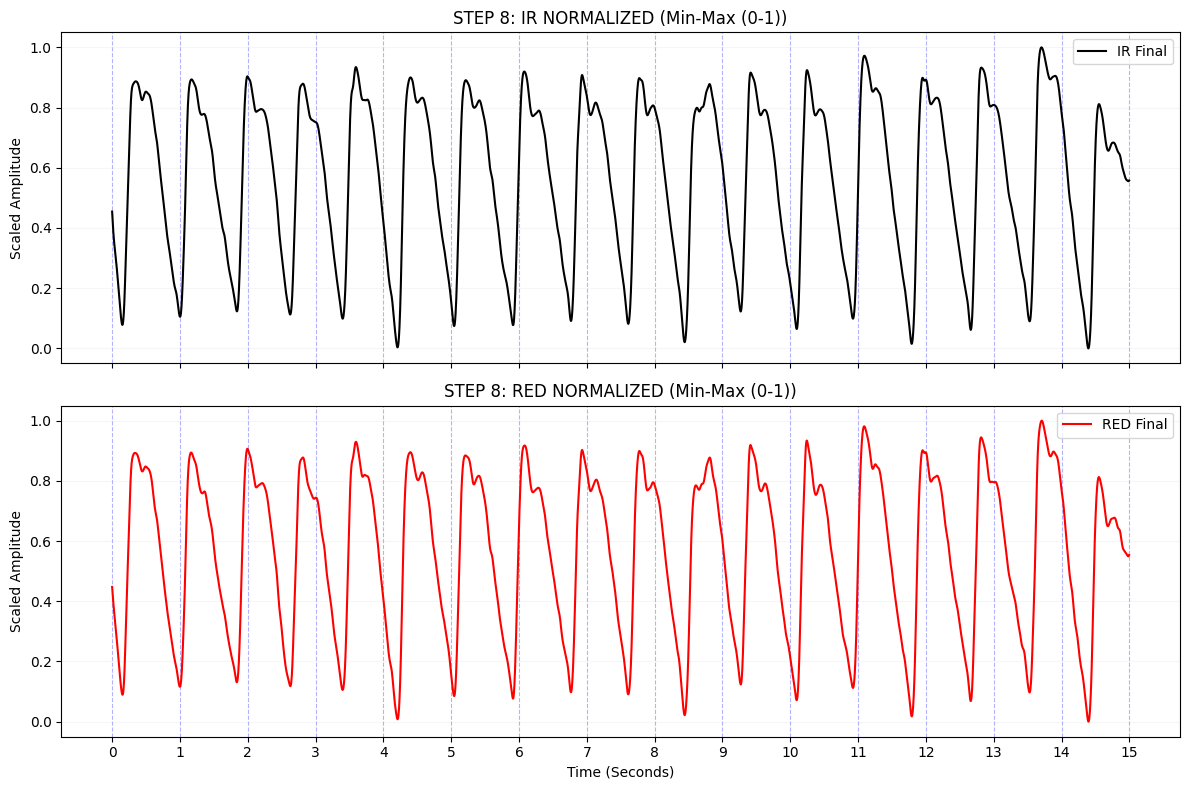


📊 FINAL STATISTICS (Check for ML Validity):
   IR  -> Min: 0.0000, Max: 1.0000, Mean: 0.5672, Std: 0.2708
   RED -> Min: 0.0000, Max: 1.0000, Mean: 0.5626, Std: 0.2680


In [9]:
# ==========================================
# ⚙️ STEP 8: NORMALIZATION
# ==========================================
# Input: ir_hpf, red_hpf (Output from Step 7)
# Output: ir_norm, red_norm (Final ML-Ready Signal)

# --- 1. Apply Normalization ---
# Uses the helper function defined in Cell 1
ir_norm  = apply_normalization(ir_hpf, selection=NORM_SELECTION)
red_norm = apply_normalization(red_hpf, selection=NORM_SELECTION)

norm_type = "Min-Max (0-1)" if NORM_SELECTION == 1 else "Z-Score (Std=1)"
print(f"⚡ NORMALIZATION APPLIED: {norm_type}")

# --- 2. Setup Plotting ---
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 2
fig, axes = plt.subplots(2, 1, figsize=(12, total_fig_height), sharex=True)
plt.subplots_adjust(hspace=0.4)

# --- PLOT 1: IR FINAL ---
axes[0].plot(time_axis, ir_norm, color='black', linewidth=1.5, label='IR Final')
axes[0].set_title(f'STEP 8: IR NORMALIZED ({norm_type})')
axes[0].set_ylabel('Scaled Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED FINAL ---
axes[1].plot(time_axis, red_norm, color='red', linewidth=1.5, label='RED Final')
axes[1].set_title(f'STEP 8: RED NORMALIZED ({norm_type})')
axes[1].set_ylabel('Scaled Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- VERTICAL LINES (Time) ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    pass # grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in axes:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(TIME_VERTICAL_LINE_INTERVAL))
        ax.grid(True, which='major', axis='x', color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', axis='y', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

# --- 3. Print Verification Stats ---
print("\n📊 FINAL STATISTICS (Check for ML Validity):")
print(f"   IR  -> Min: {np.min(ir_norm):.4f}, Max: {np.max(ir_norm):.4f}, Mean: {np.mean(ir_norm):.4f}, Std: {np.std(ir_norm):.4f}")
print(f"   RED -> Min: {np.min(red_norm):.4f}, Max: {np.max(red_norm):.4f}, Mean: {np.mean(red_norm):.4f}, Std: {np.std(red_norm):.4f}")

In [10]:
# ==========================================
# ⚙️ STEP 9: ADVANCED SIGNAL QUALITY CHECK
# ==========================================
# Evaluates if the signal is "Clean" enough for Machine Learning.
# Uses 'ir_hpf' and 'red_hpf' (Step 7 Output) to preserve true AC amplitude.

def calculate_snr(signal_data, fs):
    """
    Calculates Spectral Signal-to-Noise Ratio (SNR).
    Signal Power: 0.5 Hz to 5.0 Hz (Heartbeat range)
    Noise Power: Everything else up to Nyquist.
    """
    freqs, psd = signal.periodogram(signal_data, fs)
    sig_mask = (freqs >= 0.5) & (freqs <= 5.0)
    noise_mask = ~sig_mask 
    sig_power = np.sum(psd[sig_mask])
    noise_power = np.sum(psd[noise_mask])
    if noise_power == 0: return 100.0
    return 10 * np.log10(sig_power / noise_power)

def calculate_zcr(signal_data):
    """ Measures 'jitter' (Zero Crossing Rate). """
    # Data is already centered by HPF, but safety center again
    centered = signal_data - np.mean(signal_data)
    crossings = np.diff(np.signbit(centered)).sum()
    return crossings / len(signal_data)

def check_quality_advanced(name, clean_sig, raw_sig_for_dc, fs):
    print(f"\n📋 HIGH-STANDARD QUALITY REPORT: {name}")
    print("=" * 95)
    
    # --- 1. SKEWNESS (Symmetry) ---
    # Healthy pulses are positive skewed (fast up, slow down)
    skew = stats.skew(clean_sig)
    skew_min = SQI_LIMITS['SKEWNESS_MIN']
    skew_status = "✅ PASS" if skew > skew_min else "❌ FAIL (Distorted)"
    
    # --- 2. KURTOSIS (Sharpness) ---
    # Healthy pulses are sharp (Leptokurtic)
    kurt = stats.kurtosis(clean_sig)
    kurt_min = SQI_LIMITS['KURTOSIS_MIN']
    kurt_status = "✅ PASS" if kurt > kurt_min else "⚠️ WARNING (Flat)"
    
    # --- 3. PERFUSION INDEX (PI) ---
    # Ratio of AC Pulse strength to DC Baseline
    ac_amp = np.max(clean_sig) - np.min(clean_sig)
    dc_amp = np.mean(raw_sig_for_dc)
    pi = (ac_amp / dc_amp) * 100 if dc_amp != 0 else 0
    pi_min = SQI_LIMITS['PI_MIN']
    pi_status = "✅ PASS" if pi > pi_min else "❌ FAIL (Weak Signal)"

    # --- 4. SNR (Clarity) ---
    snr = calculate_snr(clean_sig, fs)
    snr_min = SQI_LIMITS['SNR_MIN_DB']
    snr_status = "✅ PASS" if snr > snr_min else "❌ FAIL (Too Noisy)"

    # --- 5. ZERO-CROSSING RATE (Stability) ---
    # High ZCR = White Noise
    zcr = calculate_zcr(clean_sig)
    zcr_max = SQI_LIMITS['ZCR_MAX']
    zcr_status = "✅ PASS" if zcr < zcr_max else "⚠️ WARNING (Jittery)"

    # --- PRINT TABLE ---
    print(f"{'METRIC':<20} | {'VALUE':<12} | {'TARGET':<15} | {'STATUS':<25}")
    print("-" * 95)
    print(f"{'Skewness':<20} | {skew:<12.4f} | > {skew_min:<13} | {skew_status}")
    print(f"{'Kurtosis':<20} | {kurt:<12.4f} | > {kurt_min:<13} | {kurt_status}")
    print(f"{'Perfusion Index':<20} | {pi:<12.4f}% | > {pi_min:<13}% | {pi_status}")
    print(f"{'SNR (dB)':<20} | {snr:<12.4f} | > {snr_min:<13} | {snr_status}")
    print(f"{'Zero-Crossing':<20} | {zcr:<12.4f} | < {zcr_max:<13} | {zcr_status}")
    print("=" * 95)

    # Global Verdict (Strict: Fail if Skew, PI, or SNR fail)
    if "❌" in (skew_status + pi_status + snr_status):
        print(f"🚨 FINAL VERDICT: REJECTED (Bad Signal Quality)")
        return False
    else:
        print(f"🎉 FINAL VERDICT: ACCEPTED (High Quality for AI)")
        return True

# --- EXECUTE CHECK ---
# We use ir_hpf/red_hpf (Step 7) because they have the true AC amplitude.
# We use selected_df (Step 2) for the DC baseline.

check_quality_advanced("RED CHANNEL", red_hpf, selected_df['RED'].values, FS)
check_quality_advanced("IR CHANNEL ", ir_hpf, selected_df['IR'].values, FS)


📋 HIGH-STANDARD QUALITY REPORT: RED CHANNEL
METRIC               | VALUE        | TARGET          | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | -0.3688      | > 0.0           | ❌ FAIL (Distorted)
Kurtosis             | -1.2238      | > 1.5           | ⚠️ WARNING (Flat)
Perfusion Index      | 0.6871      % | > 0.1          % | ✅ PASS
SNR (dB)             | 20.2090      | > 5.0           | ✅ PASS
Zero-Crossing        | 0.0060       | < 4.0           | ✅ PASS
🚨 FINAL VERDICT: REJECTED (Bad Signal Quality)

📋 HIGH-STANDARD QUALITY REPORT: IR CHANNEL 
METRIC               | VALUE        | TARGET          | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | -0.4013      | > 0.0           | ❌ FAIL (Distorted)
Kurtosis             | -1.2128      | > 1.5           | ⚠️ WARNING (Flat)
Perfusion Index   

False

In [11]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.signal import welch

# ==========================================
# ⚙️ STEP 10: FULL PIPELINE DIAGNOSTIC REPORT
# ==========================================

# 1. 🛠️ Define the SQI Calculation Function
def calculate_sqi_metrics(sig_ac, sig_raw_for_dc, fs):
    """
    Calculates SQI metrics for a given signal stage.
    """
    # --- SQI 1: Skewness & Kurtosis ---
    skew = stats.skew(sig_ac)
    kurt = stats.kurtosis(sig_ac)
    
    # --- SQI 2: Zero Crossing Rate (ZCR) ---
    centered = sig_ac - np.mean(sig_ac)
    zcr_count = ((centered[:-1] * centered[1:]) < 0).sum()
    zcr = zcr_count / (len(sig_ac) / fs)

    # --- SQI 3: Signal-to-Noise Ratio (SNR) ---
    f, Pxx = welch(sig_ac, fs=fs, nperseg=len(sig_ac))
    band_mask = (f >= 0.5) & (f <= 4.0) # Heart Rate Band
    signal_power = np.sum(Pxx[band_mask])
    noise_power  = np.sum(Pxx) - signal_power
    snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else 0

    # --- SQI 4: AC Amplitude & Perfusion Index (PI) ---
    # Note: We use the AC of the *current stage* but DC of the *Raw Signal*
    # This ensures PI is valid even after High-Pass Filtering (where DC ~ 0)
    ac_amp = np.max(sig_ac) - np.min(sig_ac)
    dc_val = np.mean(sig_raw_for_dc)
    pi = (ac_amp / dc_val) * 100 if dc_val != 0 else 0
    
    return skew, kurt, zcr, snr, pi, ac_amp

# 2. 📥 Gather Data from Previous Steps
# We use .get() to avoid crashing if you skipped a step
stages = [
    ("1. Raw Input",      selected_df['IR'].values,  selected_df['RED'].values),
    ("3. Despiked",       globals().get('ir_despiked'), globals().get('red_despiked')),
    ("4. Inverted",       globals().get('ir_inverted'), globals().get('red_inverted')),
    ("5. Low-Pass",       globals().get('ir_filtered'), globals().get('red_filtered')),
    ("6. SG Smoothed",    globals().get('ir_smoothed'), globals().get('red_smoothed')),
    ("7. High-Pass",      globals().get('ir_hpf'),      globals().get('red_hpf'))
]

# 3. 📊 Generate the Report
results = []

print(f"{'STAGE':<20} | {'CH':<3} | {'SKEW':<6} | {'KURT':<6} | {'ZCR':<5} | {'SNR (dB)':<8} | {'PI %':<6} | {'R-VAL':<6} | {'STATUS'}")
print("-" * 100)

for name, ir_data, red_data in stages:
    if ir_data is None or red_data is None:
        continue # Skip skipped steps

    # --- Calculate Metrics for IR ---
    # We use selected_df (Raw) for DC reference to keep PI consistent
    sk_i, ku_i, zc_i, snr_i, pi_i, ac_i = calculate_sqi_metrics(ir_data, selected_df['IR'].values, FS)
    
    # --- Calculate Metrics for RED ---
    sk_r, ku_r, zc_r, snr_r, pi_r, ac_r = calculate_sqi_metrics(red_data, selected_df['RED'].values, FS)

    # --- Calculate Ratio R ---
    # R = (AC_red / DC_red) / (AC_ir / DC_ir)
    # Since we already calculated PI = (AC/DC)*100, we can just use: R = PI_red / PI_ir
    if pi_i > 0:
        r_val = pi_r / pi_i
    else:
        r_val = 0

    # --- Quick Pass/Fail Check (Based on your Best Ranges) ---
    # Checking if SNR > 5dB and ZCR is physiological (0.5 - 4 Hz)
    status_i = "✅" if (snr_i > 5 and 0.5 < zc_i < 4.0) else "⚠️"
    status_r = "✅" if (snr_r > 5 and 0.5 < zc_r < 4.0) else "⚠️"
    
    # --- Print Row IR ---
    print(f"{name:<20} | IR  | {sk_i:6.2f} | {ku_i:6.2f} | {zc_i:5.2f} | {snr_i:8.2f} | {pi_i:6.2f} | {'-':<6} | {status_i}")
    
    # --- Print Row RED ---
    print(f"{'':<20} | RED | {sk_r:6.2f} | {ku_r:6.2f} | {zc_r:5.2f} | {snr_r:8.2f} | {pi_r:6.2f} | {r_val:6.2f} | {status_r}")
    print("-" * 100)

print("\n💡 GUIDE:")
print("   • SKEW: Best [0.5 - 1.5]. If < 0, signal is inverted/noise.")
print("   • SNR:  Best > 12dB. Tells you how 'clean' the heartbeat is.")
print("   • R:    Best [0.3 - 1.2]. The core Glucose/SpO2 predictor.")

STAGE                | CH  | SKEW   | KURT   | ZCR   | SNR (dB) | PI %   | R-VAL  | STATUS
----------------------------------------------------------------------------------------------------
1. Raw Input         | IR  |   0.12 |  -0.56 |  6.87 |    -0.30 |   2.58 | -      | ⚠️
                     | RED |   0.15 |  -0.58 | 11.80 |     0.22 |   1.20 |   0.46 | ⚠️
----------------------------------------------------------------------------------------------------
3. Despiked          | IR  |   0.12 |  -0.56 |  6.87 |    -0.30 |   2.58 | -      | ⚠️
                     | RED |   0.15 |  -0.58 | 11.80 |     0.22 |   1.20 |   0.46 | ⚠️
----------------------------------------------------------------------------------------------------
4. Inverted          | IR  |  -0.12 |  -0.56 |  6.87 |    -0.30 |   2.58 | -      | ⚠️
                     | RED |  -0.15 |  -0.58 | 11.80 |     0.22 |   1.20 |   0.46 | ⚠️
------------------------------------------------------------------------------------

In [12]:
import numpy as np
import scipy.stats as stats
from scipy.signal import find_peaks, welch

# ==========================================
# ⚙️ STEP 11: GLUCOSE FEATURE EXTRACTION QUALITY CHECK (FINAL)
# ==========================================

# ... [Previous Configuration Code remains similar, adding R limits below] ...

# 📊 UPDATED SQI LIMITS
SQI_LIMITS = {
    'SKEWNESS_MIN': 0.0,   'SKEWNESS_MAX': 2.5,   # Best: 0.5 - 1.5
    'KURTOSIS_MIN': 1.5,   'KURTOSIS_MAX': 7.0,   # Best: 2.0 - 4.0
    'PI_MIN':       0.1,   'PI_MAX':       10.0,  # Best: 0.5 - 4.0
    'SNR_MIN_DB':   5.0,   'SNR_MAX_DB':   25.0,  # Best: 12 - 25
    'ZCR_MIN':      1.0,   'ZCR_MAX':      4.0,   # Best: 1.5 - 2.5 Hz
    'R_MIN':        0.1,   'R_MAX':        3.0    # Best: 0.3 - 1.2
}

def extract_glucose_features(clean_ppg, raw_ppg, fs):
    """
    Extracts 9 Key Features (7 Glucose + 2 SQI) for Analysis.
    """
    # --- 1. Heart Rate (HR) & Peak Detection ---
    peaks, _ = find_peaks(clean_ppg, distance=int(0.4*fs), prominence=0.1)
    
    if len(peaks) > 1:
        avg_peak_interval = np.mean(np.diff(peaks)) / fs
        hr = 60.0 / avg_peak_interval if avg_peak_interval > 0 else 0
    else:
        hr = 0
    
    # --- 2. Pulse Width (Viscosity Indicator) ---
    if len(peaks) > 0:
        widths = []
        for pk in peaks:
            half_max = clean_ppg[pk] * 0.5
            left, right = pk, pk
            while left > 0 and clean_ppg[left] > half_max: left -= 1
            while right < len(clean_ppg)-1 and clean_ppg[right] > half_max: right += 1
            widths.append((right - left) / fs)
        avg_width = np.mean(widths) if widths else 0
    else:
        avg_width = 0
    
    # --- 3. Systolic Amplitude ---
    sys_amp = np.max(clean_ppg) - np.min(clean_ppg)
    
    # --- 4. Area Under Curve ---
    area = np.trapezoid(clean_ppg) if hasattr(np, 'trapezoid') else np.trapz(clean_ppg)
    
    # --- 5. Skewness (SQI Feature) ---
    skew = stats.skew(clean_ppg)
    
    # --- 6. Kurtosis (SQI Feature) ---
    kurt = stats.kurtosis(clean_ppg)
    
    # --- 7. Perfusion Index (SQI Feature) ---
    ac_real = np.max(raw_ppg) - np.min(raw_ppg)
    dc_real = np.mean(raw_ppg)
    pi = (ac_real / dc_real) * 100 if dc_real > 0 else 0

    # --- 8. Zero Crossing Rate (ZCR) (SQI Feature) ---
    centered = clean_ppg - np.mean(clean_ppg)
    zcr_count = ((centered[:-1] * centered[1:]) < 0).sum()
    zcr = zcr_count / (len(clean_ppg) / fs)

    # --- 9. Signal-to-Noise Ratio (SNR) (SQI Feature) ---
    f, Pxx = welch(clean_ppg, fs=fs, nperseg=len(clean_ppg))
    band_mask = (f >= 0.5) & (f <= 4.0)
    signal_power = np.sum(Pxx[band_mask])
    total_power  = np.sum(Pxx)
    noise_power  = total_power - signal_power
    
    snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else 100

    return {
        'hr': hr, 'width': avg_width, 'sys_amp': sys_amp, 'area': area,
        'skew': skew, 'kurt': kurt, 'pi': pi, 'zcr': zcr, 'snr': snr
    }

# ==========================================
# 📊 RUN EXTRACTION
# ==========================================
print("\n🧬 QUALITY CHECK FOR EXTRACTING AI FEATURES...")

feat_red = extract_glucose_features(red_norm, selected_df['RED'].values, FS)
feat_ir  = extract_glucose_features(ir_norm, selected_df['IR'].values, FS)

# ==========================================
# 🔄 UPDATED: ACCURATE RATIO OF RATIOS (RoR)
# ==========================================
# We use the AC/DC values calculated in Step 5 (DC) and Step 7 (AC)
# Formula: R = (AC_red / DC_red) / (AC_ir / DC_ir)

if dc_red_val != 0 and dc_ir_val != 0 and ac_ir_val != 0:
    ratio_red = ac_red_val / dc_red_val
    ratio_ir  = ac_ir_val / dc_ir_val
    ratio_of_ratios = ratio_red / ratio_ir
else:
    ratio_of_ratios = 0.0

# ==========================================
# 📝 ENGINEER'S REPORT (UPDATED)
# ==========================================
print("\n" + "="*105)
print(f"📊 PPG FEATURE EXTRACTION REPORT (WITH QUALITY CHECK)")
print("="*105)
# Header Format
print(f"{'FEATURE':<22} | {'RED':<10} | {'IR':<10} | {'MIN-MAX':<12} | {'BEST RANGE':<12} | {'UNIT'}")
print("-" * 105)

# --- Biological Features ---
print(f"{'Heart Rate (HR)':<22} | {feat_red['hr']:<10.1f} | {feat_ir['hr']:<10.1f} | {'60 - 100':<12} | {'Resting':<12} | BPM")
print(f"{'Pulse Width':<22} | {feat_red['width']:<10.4f} | {feat_ir['width']:<10.4f} | {'N/A':<12} | {'N/A':<12} | Sec")
print(f"{'Systolic Amp':<22} | {feat_red['sys_amp']:<10.4f} | {feat_ir['sys_amp']:<10.4f} | {'N/A':<12} | {'N/A':<12} | Norm")
print(f"{'Area Under Curve':<22} | {feat_red['area']:<10.4f} | {feat_ir['area']:<10.4f} | {'N/A':<12} | {'N/A':<12} | Area")

print("-" * 105) 
# --- SQI Features ---
print(f"{'Skewness':<22} | {feat_red['skew']:<10.4f} | {feat_ir['skew']:<10.4f} | {'0 - 2.5':<12} | {'0.5 - 1.5':<12} | -")
print(f"{'Kurtosis':<22} | {feat_red['kurt']:<10.4f} | {feat_ir['kurt']:<10.4f} | {'1.5 - 7.0':<12} | {'2.0 - 4.0':<12} | -")
print(f"{'Perfusion Index (PI)':<22} | {feat_red['pi']:<10.4f} | {feat_ir['pi']:<10.4f} | {'0.1 - 10':<12} | {'0.5 - 4.0':<12} | %")
print(f"{'Zero Crossing (ZCR)':<22} | {feat_red['zcr']:<10.4f} | {feat_ir['zcr']:<10.4f} | {'1.0 - 4.0':<12} | {'1.5 - 2.5':<12} | Hz")
print(f"{'SNR':<22} | {feat_red['snr']:<10.4f} | {feat_ir['snr']:<10.4f} | {'5 - 25':<12} | {'12 - 25':<12} | dB")

print("-" * 105)
# --- Final R Value (Merged Columns) ---
print(f"{'Ratio of Ratios (R)':<22} | {ratio_of_ratios:^23.4f} | {'0.1 - 3.0':<12} | {'0.3 - 1.2':<12} | Ratio")
print("="*105)


🧬 QUALITY CHECK FOR EXTRACTING AI FEATURES...

📊 PPG FEATURE EXTRACTION REPORT (WITH QUALITY CHECK)
FEATURE                | RED        | IR         | MIN-MAX      | BEST RANGE   | UNIT
---------------------------------------------------------------------------------------------------------
Heart Rate (HR)        | 71.8       | 71.8       | 60 - 100     | Resting      | BPM
Pulse Width            | 0.5311     | 0.5367     | N/A          | N/A          | Sec
Systolic Amp           | 1.0000     | 1.0000     | N/A          | N/A          | Norm
Area Under Curve       | 3374.8025  | 3402.5523  | N/A          | N/A          | Area
---------------------------------------------------------------------------------------------------------
Skewness               | -0.3688    | -0.4013    | 0 - 2.5      | 0.5 - 1.5    | -
Kurtosis               | -1.2238    | -1.2128    | 1.5 - 7.0    | 2.0 - 4.0    | -
Perfusion Index (PI)   | 1.1976     | 2.5771     | 0.1 - 10     | 0.5 - 4.0    | %
Zero Cross


📉 GENERATING ENSEMBLE PLOTS (THIN BLACK LINES)...
   -> Morphology Window Found: Pre=0.165s, Post=0.680s
✅ RED Channel: Used 17 individual PPG signals for Ensembling.


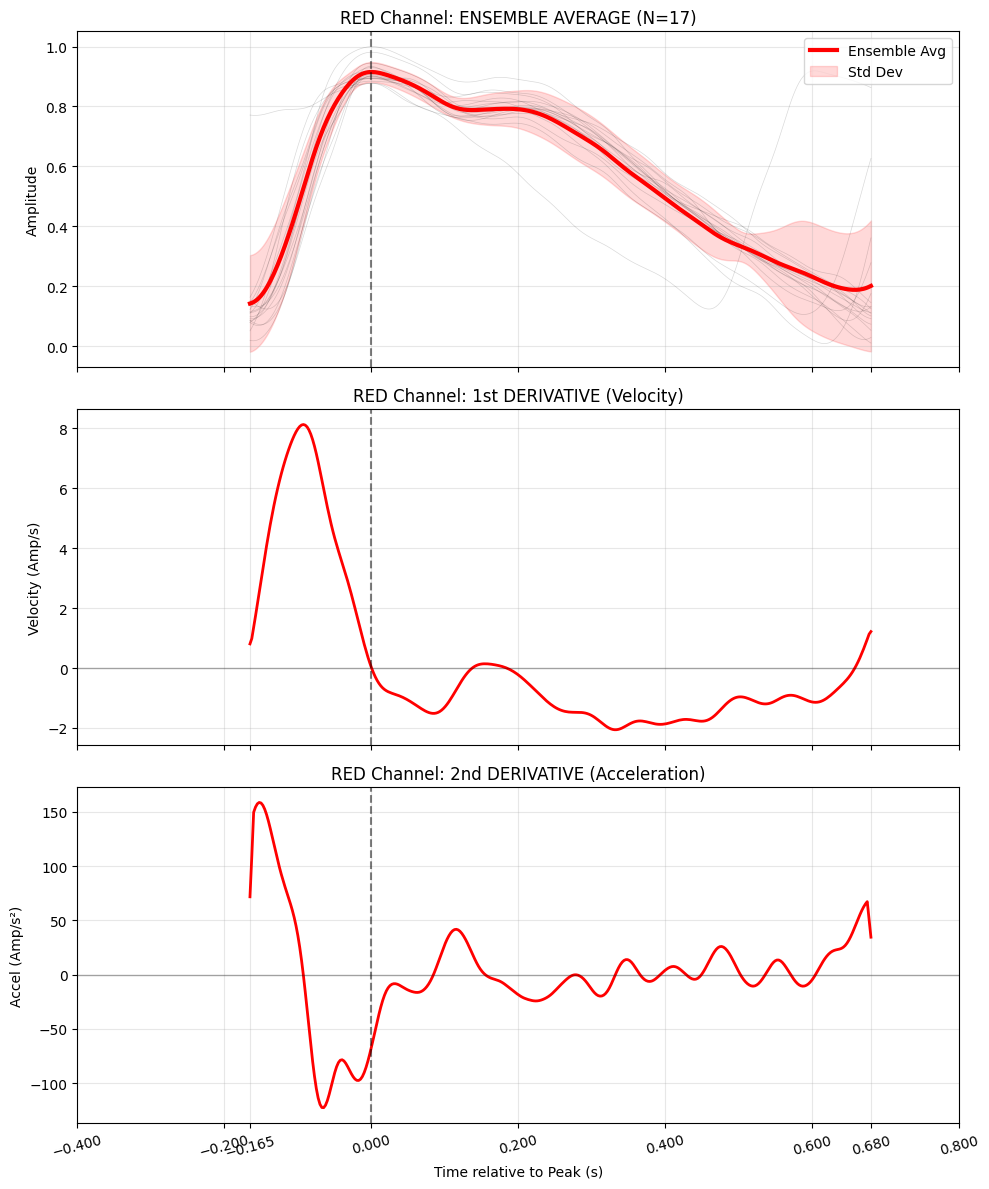

   -> Morphology Window Found: Pre=0.166s, Post=0.677s
✅ IR Channel: Used 17 individual PPG signals for Ensembling.


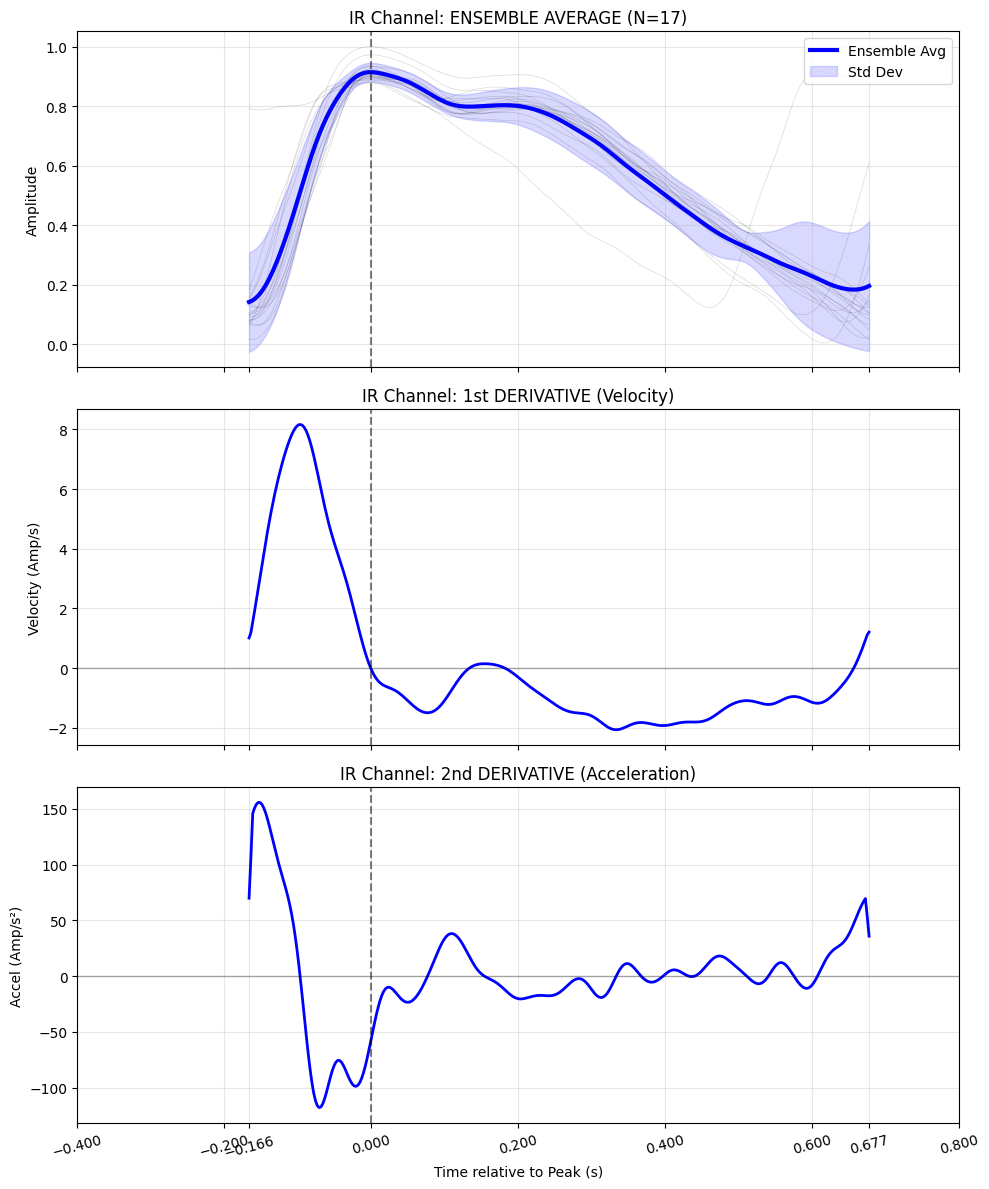


📊 ENSEMBLE SUMMARY:
   🔴 Red Beats Used: 17
   🔵 IR  Beats Used: 17


In [13]:
# ==========================================
# ⚙️ STEP 11: ENSEMBLE AVERAGING (Final Polish)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks

def get_morphology_based_window(signal_data, fs):
    """
    Calculates window size based on 'Zero-Derivative & Lowest Amplitude' logic.
    Returns: avg_pre_sec, avg_post_sec
    """
    # 1. Find Systolic Peaks (Max)
    peaks, _ = find_peaks(signal_data, distance=int(0.4*fs), prominence=0.1)
    
    # 2. Find Valleys (Local Minima where 1st Derivative is Zero)
    valleys, _ = find_peaks(-signal_data, distance=int(0.2*fs))
    
    if len(peaks) < 3 or len(valleys) < 3:
        return 0.3, 0.7 # Fallback
        
    left_distances = []
    right_distances = []
    
    # 3. Iterate through peaks to find true feet
    for i in range(1, len(peaks)-1):
        current_peak = peaks[i]
        prev_peak    = peaks[i-1]
        next_peak    = peaks[i+1]
        
        # --- LEFT SIDE (Pre-Peak) ---
        candidates_left = valleys[(valleys > prev_peak) & (valleys < current_peak)]
        if len(candidates_left) > 0:
            amps = signal_data[candidates_left]
            best_valley_idx = np.argmin(amps)
            true_foot_left = candidates_left[best_valley_idx]
            left_distances.append((current_peak - true_foot_left) / fs)
            
        # --- RIGHT SIDE (Post-Peak) ---
        candidates_right = valleys[(valleys > current_peak) & (valleys < next_peak)]
        if len(candidates_right) > 0:
            amps = signal_data[candidates_right]
            best_valley_idx = np.argmin(amps)
            true_foot_right = candidates_right[best_valley_idx]
            right_distances.append((true_foot_right - current_peak) / fs)
            
    # 4. Use MEDIAN to define the standard window
    if not left_distances or not right_distances:
        return 0.3, 0.7
        
    avg_pre_sec  = np.median(left_distances)
    avg_post_sec = np.median(right_distances)
    
    print(f"   -> Morphology Window Found: Pre={avg_pre_sec:.3f}s, Post={avg_post_sec:.3f}s")
    return avg_pre_sec, avg_post_sec

def plot_ensemble_with_derivatives(signal_data, fs, title, color_avg):
    """
    Plots Ensemble Average (Bold Color) over Individual Beats (Thin Black Lines).
    Returns: Number of beats used.
    """
    # --- 1. Determine Window Size ---
    pre_peak_sec, post_peak_sec = get_morphology_based_window(signal_data, fs)
    
    pre_samples  = int(pre_peak_sec * fs)
    post_samples = int(post_peak_sec * fs)
    window_len   = pre_samples + post_samples
    
    # --- 2. Segment the Signal ---
    peaks, _ = find_peaks(signal_data, distance=int(0.4*fs), prominence=0.1)
    
    if len(peaks) < 2:
        print(f"⚠️ Not enough peaks in {title}.")
        return 0

    segments = []
    for p in peaks:
        if p - pre_samples >= 0 and p + post_samples < len(signal_data):
            seg = signal_data[p - pre_samples : p + post_samples]
            segments.append(seg)
    
    if not segments:
        print("⚠️ No valid segments extracted.")
        return 0

    # ---------------------------------------------------------
    # 📊 OUTPUT: PRINT NUMBER OF BEATS USED
    # ---------------------------------------------------------
    count_beats = len(segments)
    print(f"✅ {title}: Used {count_beats} individual PPG signals for Ensembling.")
    # ---------------------------------------------------------

    segments_matrix = np.array(segments)
    
    # --- 3. Calculate Math (Average & Derivatives) ---
    avg_wave = np.mean(segments_matrix, axis=0)
    std_wave = np.std(segments_matrix, axis=0)
    
    # Derivatives
    velocity_wave = np.gradient(avg_wave) * fs
    acceleration_wave = np.gradient(velocity_wave) * fs
    
    # --- 4. Plotting (3 Rows) ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
    # Time Axis
    time_axis = np.linspace(-pre_peak_sec, post_peak_sec, window_len)
    
    # ROW 1: ENSEMBLE AVERAGE + INDIVIDUAL BEATS
    ax1 = axes[0]
    for seg in segments:
        ax1.plot(time_axis, seg, color='black', alpha=0.15, linewidth=0.5) 
    
    ax1.plot(time_axis, avg_wave, color=color_avg, linewidth=3, label='Ensemble Avg')
    ax1.fill_between(time_axis, avg_wave - std_wave, avg_wave + std_wave, 
                     color=color_avg, alpha=0.15, label='Std Dev')
                     
    ax1.set_title(f"{title}: ENSEMBLE AVERAGE (N={count_beats})")
    ax1.set_ylabel("Amplitude")
    ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # ROW 2: VELOCITY (1st Derivative)
    ax2 = axes[1]
    ax2.plot(time_axis, velocity_wave, color=color_avg, linewidth=2)
    ax2.set_title(f"{title}: 1st DERIVATIVE (Velocity)")
    ax2.set_ylabel("Velocity (Amp/s)")
    ax2.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax2.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.3) # Zero Line
    ax2.grid(True, alpha=0.3)
    
    # ROW 3: ACCELERATION (2nd Derivative)
    ax3 = axes[2]
    ax3.plot(time_axis, acceleration_wave, color=color_avg, linewidth=2)
    ax3.set_title(f"{title}: 2nd DERIVATIVE (Acceleration)")
    ax3.set_ylabel("Accel (Amp/s²)")
    ax3.set_xlabel("Time relative to Peak (s)")
    ax3.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax3.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    ax3.grid(True, alpha=0.3)

    # 📏 X-AXIS UPDATE: Add Start and End Point Labels
    # We get existing ticks, add our custom start/end times, and re-apply
    current_ticks = list(ax3.get_xticks())
    custom_ticks = sorted(list(set(current_ticks + [time_axis[0], time_axis[-1]])))
    
    # Apply to the bottom axis (shared x-axis)
    ax3.set_xticks(custom_ticks)
    # Rotate slightly to prevent overlap if crowded
    ax3.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()
    
    return count_beats

# ==========================================
# 🏃‍♂️ RUN ENSEMBLE PLOTTING
# ==========================================
print("\n📉 GENERATING ENSEMBLE PLOTS (THIN BLACK LINES)...")

# 1. Red Channel 
n_red_beats = plot_ensemble_with_derivatives(red_norm, FS, "RED Channel", "red")

# 2. IR Channel (Average is Blue to contrast with black lines)
n_ir_beats = plot_ensemble_with_derivatives(ir_norm, FS, "IR Channel", "blue")

# 📝 FINAL COUNT DISPLAY
print("\n" + "="*40)
print(f"📊 ENSEMBLE SUMMARY:")
print(f"   🔴 Red Beats Used: {n_red_beats}")
print(f"   🔵 IR  Beats Used: {n_ir_beats}")
print("="*40)

In [14]:
# ==========================================
# ⚙️ STEP 12: FEATURE EXTRACTION (Ensemble Average)
# ==========================================
import numpy as np
import scipy.stats as stats
from scipy.signal import find_peaks

# --- 1. Helper: Generate the Data (No Plotting) ---
def get_ensemble_wave(signal_data, fs):
    """
    Returns the single averaged heartbeat waveform.
    """
    peaks, _ = find_peaks(signal_data, distance=int(0.4*fs), prominence=0.1)
    
    if len(peaks) < 2:
        return None, 0

    # Window: 0.2s before peak, 0.6s after (Standard PPG morphology)
    pre_samples  = int(0.2 * fs)
    post_samples = int(0.6 * fs)
    
    segments = []
    for p in peaks:
        if p - pre_samples >= 0 and p + post_samples < len(signal_data):
            seg = signal_data[p - pre_samples : p + post_samples]
            segments.append(seg)
    
    if not segments: return None, 0

    # Calculate Average
    avg_wave = np.mean(segments, axis=0)
    return avg_wave, len(peaks) # Return wave and number of beats averaged

# --- 2. Helper: Extract Features from Single Beat ---
def extract_features_from_beat(beat_wave, global_hr, raw_signal_for_dc, fs):
    """
    Extracts morphology features from the single averaged beat.
    """
    if beat_wave is None:
        return {}

    # A. Pulse Width (Viscosity) - tailored for single beat
    #    We find the max point (peak) and measure width at 50% height
    peak_idx = np.argmax(beat_wave)
    half_max = beat_wave[peak_idx] * 0.5
    
    left, right = peak_idx, peak_idx
    while left > 0 and beat_wave[left] > half_max:
        left -= 1
    while right < len(beat_wave)-1 and beat_wave[right] > half_max:
        right += 1
    
    pulse_width = (right - left) / fs

    # B. Area Under Curve (Blood Volume)
    if hasattr(np, 'trapezoid'):
        area = np.trapezoid(beat_wave)
    else:
        area = np.trapz(beat_wave)

    # C. Systolic Amplitude (Normalized)
    sys_amp = np.max(beat_wave) - np.min(beat_wave)

    # D. Skewness & Kurtosis (Shape)
    skew = stats.skew(beat_wave)
    kurt = stats.kurtosis(beat_wave)

    # E. Perfusion Index (PI) - MUST use Global Raw DC
    #    The ensemble average is normalized, so it lost amplitude info.
    #    We use the global DC baseline from the raw signal.
    #    We estimate AC from the ensemble amplitude, scaled? No, safer to use Global AC.
    #    Actually, best practice: Use Global PI, but Beat Shape.
    ac_global = np.max(raw_signal_for_dc) - np.min(raw_signal_for_dc)
    dc_global = np.mean(raw_signal_for_dc)
    pi = (ac_global / dc_global) * 100 if dc_global > 0 else 0

    return {
        'HR_Global': global_hr,       # From Step 10 (Rate)
        'Width_Avg': pulse_width,     # From Ensemble (Shape)
        'Area_Avg':  area,            # From Ensemble (Shape)
        'Amp_Avg':   sys_amp,         # From Ensemble (Shape)
        'Skew_Avg':  skew,            # From Ensemble (Shape)
        'Kurt_Avg':  kurt,            # From Ensemble (Shape)
        'PI_Global': pi               # From Raw Data (Amplitude)
    }

# ==========================================
# 🏃‍♂️ RUN EXTRACTION
# ==========================================
print("\n🧬 EXTRACTING FEATURES FROM ENSEMBLE AVERAGE...")

# 1. Get the "Perfect Waves"
avg_wave_ir, n_beats_ir   = get_ensemble_wave(ir_norm, FS)
avg_wave_red, n_beats_red = get_ensemble_wave(red_norm, FS)

# 2. Extract Features (Combining Ensemble Shape + Global Stats)
#    Note: We pass feat_ir['hr'] from Step 10 as the global HR
final_feat_ir = extract_features_from_beat(avg_wave_ir, feat_ir['hr'], selected_df['IR'].values, FS)
final_feat_red = extract_features_from_beat(avg_wave_red, feat_red['hr'], selected_df['RED'].values, FS)

# ==========================================
# 📊 FINAL "GOLDEN" REPORT
# ==========================================
print("\n" + "="*95)
print(f"🌟 GOLDEN STANDARD FEATURE REPORT (Averaged over {n_beats_ir} Beats)")
print("="*95)
print(f"{'FEATURE':<25} | {'RED (Avg)':<15} | {'IR (Avg)':<15} | {'Significance'}")
print("-" * 95)

# Heart Rate
print(f"{'Heart Rate':<25} | {final_feat_red['HR_Global']:<15.1f} | {final_feat_ir['HR_Global']:<15.1f} | Global BPM")

# Pulse Width (The Star Feature for Glucose)
print(f"{'Pulse Width':<25} | {final_feat_red['Width_Avg']:<15.4f} | {final_feat_ir['Width_Avg']:<15.4f} | *Viscosity Indicator*")

# Area
print(f"{'Area Under Curve':<25} | {final_feat_red['Area_Avg']:<15.4f} | {final_feat_ir['Area_Avg']:<15.4f} | Blood Volume Profile")

# Skewness
print(f"{'Skewness':<25} | {final_feat_red['Skew_Avg']:<15.4f} | {final_feat_ir['Skew_Avg']:<15.4f} | Wave Symmetry")

# Kurtosis
print(f"{'Kurtosis':<25} | {final_feat_red['Kurt_Avg']:<15.4f} | {final_feat_ir['Kurt_Avg']:<15.4f} | Peak Sharpness")

# PI
print(f"{'Perfusion Index':<25} | {final_feat_red['PI_Global']:<15.4f} | {final_feat_ir['PI_Global']:<15.4f} | Signal Strength (%)")

print("="*95)


🧬 EXTRACTING FEATURES FROM ENSEMBLE AVERAGE...

🌟 GOLDEN STANDARD FEATURE REPORT (Averaged over 18 Beats)
FEATURE                   | RED (Avg)       | IR (Avg)        | Significance
-----------------------------------------------------------------------------------------------
Heart Rate                | 71.8            | 71.8            | Global BPM
Pulse Width               | 0.5225          | 0.5250          | *Viscosity Indicator*
Area Under Curve          | 186.5433        | 188.1831        | Blood Volume Profile
Skewness                  | -0.3252         | -0.3589         | Wave Symmetry
Kurtosis                  | -1.3103         | -1.3007         | Peak Sharpness
Perfusion Index           | 1.1976          | 2.5771          | Signal Strength (%)


In [15]:
# If you're in VSCode/Jupyter and plots don't respond, this backend is the key.
# Do NOT use "%matplotlib widget" if it throws errors on your setup.
# ipympl backend name is the safest:
%matplotlib ipympl

import matplotlib.pyplot as plt
plt.ioff()  # prevents accidental blocking behavior

In [16]:
# ==========================================
# 💾 STEP 13: SAVE PROCESSED DATA & CHECKPOINTING (FIXED)
# ==========================================

import os
import json
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n" + "="*50)
print("💾 DATA EXPORT & CHECKPOINTING")
print("="*50)

# ---------------------------------------------------------
# 1. SETUP PATHS & NAMES
# ---------------------------------------------------------
save_root = r'C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered'

base_filename = os.path.splitext(os.path.basename(FILENAME))[0]
folder_name = f"{base_filename}_Filtered"
full_save_path = os.path.join(save_root, folder_name)

file_full     = f"{base_filename}_Filtered_Full.csv"
file_ensemble = f"{base_filename}_Filtered_Ensemble.csv"
file_config   = f"{base_filename}_Filtered_Configuration.json"

print("\n" + "-"*30)
print("⚠️  CONFIRMATION REQUIRED")
print("-" * 30)
print(f"📍 Target Location:  {full_save_path}")
print(f"📄 1. Full Signal:   {file_full}")
print(f"📄 2. Ensemble Wave: {file_ensemble}")
print(f"📄 3. Configuration: {file_config}")
print("-" * 30)

out = widgets.Output()

btn_save = widgets.Button(description="✅ Save Files", button_style="success")
btn_cancel = widgets.Button(description="❌ Cancel", button_style="danger")
btn_box = widgets.HBox([btn_save, btn_cancel])

# ---------------------------------------------------------
# 2. SAVE LOGIC (ONLY RUNS AFTER BUTTON CLICK)
# ---------------------------------------------------------
def do_save():

    # 1️⃣ Ensure directory exists
    os.makedirs(full_save_path, exist_ok=True)
    print(f"\n📁 Directory Ready: {full_save_path}")

    # 2️⃣ SAVE FULL SIGNAL
    df_full = pd.DataFrame({
        'Red_AC_HighPass':  red_hpf,
        'IR_AC_HighPass':   ir_hpf,
        'Red_DC_LowPass':   red_filtered,
        'IR_DC_LowPass':    ir_filtered,
        'Red_Normalized':   red_norm,
        'IR_Normalized':    ir_norm
    })

    path_full = os.path.join(full_save_path, file_full)
    df_full.to_csv(path_full, index=False)
    print(f"   ✅ Saved Full Signals: {file_full}")

    # 3️⃣ SAVE ENSEMBLE
    df_ensemble = pd.DataFrame({
        'Red_Ensemble_Avg': avg_wave_red,
        'IR_Ensemble_Avg':  avg_wave_ir
    })

    path_ensemble = os.path.join(full_save_path, file_ensemble)
    df_ensemble.to_csv(path_ensemble, index=False)
    print(f"   ✅ Saved Ensemble Wave: {file_ensemble}")

    # 4️⃣ SAVE CONFIG JSON
    total_samples = len(red_hpf)
    plot_time     = total_samples / float(FS)
    nyquist_rate  = float(FS) / 2.0

    config_data = {
        "Metadata": {
            "Source_File": FILENAME,
            "Sampling_Rate_FS": float(FS),
            "Total_Samples": int(total_samples),
            "Plot_Duration_Sec": float(plot_time),
            "Nyquist_Rate": float(nyquist_rate),
            "Date_Processed": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
        },
        "Results": {
            "Ratio_of_Ratios": float(ratio_of_ratios) if "ratio_of_ratios" in globals() else None
        },
        "Processing_Settings": {
            "Invert_Enable": bool(INVERT_ENABLE),
            "Normalization_Method": int(NORM_SELECTION),
            "Low_Pass_Filter": {
                "Enabled": bool(LP_ENABLE),
                "Cutoff_Hz": float(LP_CUTOFF) if LP_ENABLE else None,
                "Order": int(LP_ORDER) if LP_ENABLE else None
            },
            "High_Pass_Filter": {
                "Enabled": bool(HP_ENABLE),
                "Cutoff_Hz": float(HP_CUTOFF) if HP_ENABLE else None,
                "Order": int(HP_ORDER) if HP_ENABLE else None
            },
            "Savitzky_Golay": {
                "Enabled": bool(SG_ENABLE),
                "Window_Size": int(SG_WINDOW) if SG_ENABLE else None,
                "Polynomial_Order": int(SG_POLY) if SG_ENABLE else None
            }
        }
    }

    path_config = os.path.join(full_save_path, file_config)
    with open(path_config, "w") as f:
        json.dump(config_data, f, indent=4)

    print(f"   ✅ Saved Configuration JSON: {file_config}")

    print("\n🎉 ALL FILES SAVED SUCCESSFULLY.\n")


# ---------------------------------------------------------
# 3. BUTTON CALLBACKS
# ---------------------------------------------------------
def on_save_clicked(_):
    btn_save.disabled = True
    btn_cancel.disabled = True
    with out:
        clear_output(wait=True)
        print("💾 Saving started...")
        try:
            do_save()
        except Exception as e:
            print("\n❌ Save failed with error:")
            print(e)

def on_cancel_clicked(_):
    btn_save.disabled = True
    btn_cancel.disabled = True
    with out:
        clear_output(wait=True)
        print("\n❌ Saving Cancelled by User.")

btn_save.on_click(on_save_clicked)
btn_cancel.on_click(on_cancel_clicked)

display(widgets.HTML(
    f"<b>Export Confirmation</b><br>"
    f"<code>{full_save_path}</code><br><br>"
    f"Click <b>Save Files</b> to export, or <b>Cancel</b> to skip."
))
display(btn_box, out)


💾 DATA EXPORT & CHECKPOINTING

------------------------------
⚠️  CONFIRMATION REQUIRED
------------------------------
📍 Target Location:  C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Filtered\Raafiq(22-enc-05)v1_Win0_Filtered
📄 1. Full Signal:   Raafiq(22-enc-05)v1_Win0_Filtered_Full.csv
📄 2. Ensemble Wave: Raafiq(22-enc-05)v1_Win0_Filtered_Ensemble.csv
📄 3. Configuration: Raafiq(22-enc-05)v1_Win0_Filtered_Configuration.json
------------------------------


HTML(value='<b>Export Confirmation</b><br><code>C:\\Users\\DELL\\Documents\\GitHub\\fyp\\05_Data_Storage\\Filt…

Output()